In [1]:
setwd("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb")
devtools::load_all("utils/modules/R/gwastools")
library(data.table)
library(pROC)
library(reshape2)
library(bigstatsr)
library(ggplot2)
library(ggrastr)
library(ggrepel)
library(ggforce)
library(ggrepel)
source("scripts/post_hoc/utils.R")

# map from ENSEMBL to HGNC
bridge <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/biomart/220524_hgnc_ensg_enst_chr_pos.txt.gz")
ensembl_to_hgnc <- bridge$hgnc_symbol
names(ensembl_to_hgnc) <- bridge$ensembl_gene_id
ensembl_to_pos <- (bridge$start_position + bridge$end_position)/2
names(ensembl_to_pos) <- bridge$ensembl_gene_id
ensembl_to_contig <- bridge$chromosome_name
names(ensembl_to_contig) <- bridge$ensembl_gene_id

i Loading gwastools

Loading required package: data.table

Loading required package: ggplot2

Loading required package: stringr

! Adding files missing in collate: /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/gwastools/R/which_overlap.R

Type 'citation("pROC")' for a citation.


Attaching package: 'pROC'


The following objects are masked from 'package:stats':

    cov, smooth, var



Attaching package: 'reshape2'


The following objects are masked from 'package:data.table':

    dcast, melt




In [3]:
list_files_saige <- function(cond="none", prs="include", regex = "\\.txt\\.gz"){

    # set up paths
    wd <- "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb"
    step2_dir <- file.path(wd, "data/saige/output/binary/step2/min_mac4")
    step2_common_dir <- file.path(wd, "data/saige/output/binary/step2_common/min_mac4")
    step2_rare_dir <- file.path(wd, "data/saige/output/binary/step2_rare_cond/min_mac4")
    step2_combined_dir <- file.path(wd, "data/saige/output/binary/step2_rare_cond/min_mac4")
    #step2_collapsed_dir <- file.path(wd, "data/saige/output/binary/step2_collapsed/min_mac4")
    
    # subset paths based on condions
    if (cond %in% "none"){
        files <- list.files(step2_dir, full.names = TRUE, pattern = regex)
    } else if (cond %in% "common"){
        files <- list.files(step2_common_dir, full.names = TRUE, pattern = regex)
    } else if (cond %in% "rare"){
        files <- list.files(step2_rare_dir, full.names = TRUE, pattern = regex)
    } else if (cond %in% "combined"){
        files <- list.files(step2_combined_dir, full.names = TRUE, pattern = regex)
    } else {
        stop(paste(cond, "is not a valid. Try 'none','common','rare' or 'combined'"))
    }
    
    # perform final subset by PRS
    files <- sort(files)
    is_prs <- grepl("locoprs.txt.gz", files)
    if (prs %in% "include"){
        return(files)
    } else if (prs %in% "exclude"){
        # exclude any PRS files
        return(files[!is_prs])
    } else if (prs %in% "only") {
        # only include PRS
        return(files[is_prs])
    } else if (prs %in% "prefer") {
        return(gwastools::unique_but_prefer_regex(files, regex="_locoprs"))
    } else {
        stop(paste(prs, "is not valid. Must be either 'include','exclude','prefer' or 'only'."))
    }
    
}

# 1.0 Aggregate SAIGE results

In [ ]:
read_files <- function(path){
    if (file.exists(path)){
        bname <- basename(path)
        bname <- gsub(".txt.gz","", bname)
        bname <- gsub("_locoprs", "", bname)
        phenotype <- gsub("(ukb_eur_wes_200k_)|(_pLoF_damaging_missense)","",bname)
        d <- fread(path)
        d$phenotype <- phenotype
        d$prs <- grepl("locoprs", path)
        return(d)
    } else {
        write(paste(path, "does not exists."),stderr())
    }

}

get_saige_path <- function(phenotype, dir, prefer_prs=TRUE){
    # setup paths
    stopifnot(length(phenotype)==1)
    stopifnot(length(dir)==1)
    target_no_prs <- paste0("ukb_eur_wes_200k_", phenotype,"_pLoF_damaging_missense.txt.gz", sep = "")
    target_prs <- paste0("ukb_eur_wes_200k_", phenotype,"_pLoF_damaging_missense_locoprs.txt.gz", sep = "")
    target_no_prs <- file.path(dir, target_no_prs)
    target_prs <- file.path(dir, target_prs)
    # check if files exists
    file_no_prs_exists <- file.exists(target_no_prs)
    file_prs_exists <- file.exists(target_prs)
    if ((file_no_prs_exists) & (file_prs_exists)) {
        if (prefer_prs) {
            return(target_prs)
        } else {
            return(target_no_prs)
        }
    } else if (file_prs_exists){
        return(target_prs)
    } else if (file_no_prs_exists){
        return(target_no_prs)
    } else {
        write(paste0(target_no_prs, " does not exist (with or without PRS). Skipping"), stdout())
    }
}

In [ ]:
new_saige_cols <- c(
    'CHR', 'POS', 'ensembl_gene_id', 'pseudo_allele1', 'pseudo_allele2', 'KO_count', 'KO_freq',
    'MissingRate', 'BETA', 'SE', 'Tstat', 'var', 'p.value', 'p.value.NA', 'Is.SPA', 
    'KO_freq_case', 'KO_freq_ctrl', 'N_case', 'N_ctrl', 'N_case_ko', 'N_case_het', 'N_ctrl_ko',
    'N_ctrl_het', 'phenotype', "prs"
    )

new_saige_cols_c <- c(
    'CHR','POS','ensembl_gene_id','pseudo_allele1', 'pseudo_allele2', 'KO_count', 'KO_freq',
    'MissingRate','BETA','SE','Tstat','var','p.value','p.value.NA','Is.SPA',
    'KO_freq_case', 'KO_freq_ctrl','N_case','N_ctrl','BETA_c','SE_c','Tstat_c','var_c',
    'p.value_c','p.value.NA_c'
)

In [ ]:
header <- fread("data/phenotypes/dec22_phenotypes_binary_200k_header.tsv", header = FALSE)$V1

## 1.1 No conditioning

In [ ]:
targets <- paste0("ukb_eur_wes_200k_",header, "_pLoF_damaging_missense.txt.gz", sep = "")
directory <- "data/saige/output/binary/step2/min_mac4"
# load files
files_all <- file.path(directory, targets)
lst_all <- lapply(files_all, read_files)
dt_all <- do.call(rbind, lst_all)
colnames(dt_all) <- new_saige_cols
# remove redundant rows
dt_all$KO_count <- (dt_all$KO_count / 2)
dt_all$N_ctrl_het <- NULL
dt_all$N_case_het <- NULL

In [ ]:
dt_all_subset <- dt_all[(dt_all$KO_count >= 2) & (dt_all$N_case_ko >= 1) & (dt_all$p.value <= 5e-6),]
nrow(dt_all_subset)

## 1.2 Conditioniong on PRS

In [129]:
targets <- paste0("ukb_eur_wes_200k_",header, "_pLoF_damaging_missense_locoprs.txt.gz", sep = "")
directory <- "data/saige/output/binary/step2/min_mac4"
files_prs <- file.path(directory, targets)

In [130]:
lst_prs <- lapply(files_prs, read_files)
dt_prs <- do.call(rbind, lst_prs)
colnames(dt_prs) <- new_saige_cols

In [131]:
dt_prs$p.value <- as.numeric(dt_prs$p.value)
dt_prs_subset <- dt_prs[(dt_prs$KO_count >= 3) & (dt_prs$N_case_ko >= 1) & (dt_prs$p.value <= 5e-6),]

## 1.3 Common conditional analysis with NO prs

This is just to get an overview of the conditioning process.

In [206]:
# get phenotypes in which common markers have been used for conditioning
common_markers <- list.files("data/saige/output/binary/step2_common_cond/min_mac4", pattern = "markers")
phenotypes_with_common_markers <- stringr::str_extract(common_markers, "chr[0-9]+_([a-z]|[A-Z]|[0-9]|\\_)+pLoF")
phenotypes_with_common_markers <- gsub('(chr[0-9]+_)|(_pLoF)','', phenotypes_with_common_markers)

# make sure that these match with spa iter files
spa_iter_paths_full <- list.files("data/conditional/common/spa_iter", pattern = "markers", full.names = TRUE)
spa_iter_paths <- basename(spa_iter_paths_full)
phenotypes <- stringr::str_extract(spa_iter_paths, "200k_([a-z]|[A-Z]|[0-9]|\\_)+pLoF")
phenotypes <- gsub('(200k_)|(_pLoF)','', phenotypes)
stopifnot(all(phenotypes %in% phenotypes_with_common_markers))
stopifnot(all(phenotypes_with_common_markers %in% phenotypes))
genes <- stringr::str_extract(spa_iter_paths, "([A-Z]|[0-9])+.markers")
genes <- gsub(".markers","", genes)
spa_dt <- data.table(phenotypes, genes, spa_iter_paths_full)

spa_full <- do.call(rbind, lapply(1:nrow(spa_dt), function(idx){
    gene <- spa_dt$genes[idx]
    path <- spa_dt$spa_iter_paths_full[idx]
    d <- fread(path)
    colnames(d) <- c("iteration", "marker", "marker_type","p.value","p.value_cutoff", "phenotype", "all_markers")
    d <- cbind(gene, d)
    d <- d[,c("phenotype", "gene", "marker", "iteration","p.value","p.value_cutoff", "all_markers")]
    return(d)
}))


# write table with conditioniong steps
spa_full$id <- paste0(spa_full$gene, "_", spa_full$phenotype)
fwrite(spa_full, "data/post_hoc/results/spa_iter_no_prs_steps.txt", sep = "\t", quote = FALSE, na = "NA")

In [207]:
# get common files
targets <- paste0("ukb_eur_wes_200k_",phenotypes, "_pLoF_damaging_missense.txt.gz", sep = "")
directory <- "data/saige/output/binary/step2_common_cond_no_prs/min_mac4"
files_common <- file.path(directory, targets)
lst_common <- lapply(files_common, read_files)
dt_common <- do.call(rbind, lst_common)
# subset to the genes we are interested in                       
dt_common$id <- paste0(dt_common$MarkerID,"_",dt_common$phenotype)
dt_common <- dt_common[dt_common$id %in% spa_full$id,]
dt_common$id <- NULL

In [208]:
# get common prs files
targets <- paste0("ukb_eur_wes_200k_",phenotypes, "_pLoF_damaging_missense_locoprs.txt.gz", sep = "")
directory <- "data/saige/output/binary/step2_common_cond/min_mac4"
files_prs_common <- file.path(directory, targets)
lst_prs_common <- lapply(files_prs_common, read_files)
dt_prs_common <- do.call(rbind, lst_prs_common)
# subset to the genes we are interested in                       
dt_prs_common$id <- paste0(dt_prs_common$MarkerID,"_",dt_prs_common$phenotype)
dt_prs_common <- dt_prs_common[dt_prs_common$id %in% spa_full$id,]
dt_prs_common <- dt_prs_common[dt_prs_common$prs == TRUE,]
dt_prs_common$id <- NULL

In [219]:
# combine with and without PRS
dt_common_combined <- rbind(dt_common, dt_prs_common)
dt_common_combined <- dt_common_combined[order(dt_common_combined$phenotype),]
colnames(dt_common_combined)[1:25] <- new_saige_cols_c
dt_common_combined <- cbind(phenotype=dt_common_combined$phenotype, dt_common_combined[,-c("phenotype")])

fwrite(dt_common_combined, "data/post_hoc/results/spa_cond_prs_common.txt", sep = '\t', quote = FALSE, na = "NA")

In [220]:
d <- fread("data/prs/scores/BC_combined_pgs.txt.gz")

In [223]:
d <- fread("data/knockouts/alt/pp90/recoded_syn/ukb_eur_wes_200k_chr22.pp90.recoded.synonymous.txt.gz")

In [227]:
samples <- unique(d$s)
length(samples)

[1] 176587

In [118]:
get_path_phenotype("CAD_combined", "data/saige/output/binary/step2/min_mac4/")

data/saige/output/binary/step2/min_mac4//ukb_eur_wes_200k_CAD_combiffned_pLoF_damaging_missense.txt.gz does not exist (with or without PRS). Skipping


In [107]:
lapply(lst, head)

CHR,POS,MarkerID,Allele1,Allele2,AC_Allele2,AF_Allele2,MissingRate,BETA,SE,,N_case,N_ctrl,BETA_c,SE_c,Tstat_c,var_c,p.value_c,p.value.NA_c,phenotype,prs
<chr>,<int>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
chr1,13,ENSG00000007933,RCoW,nAsl,12,3.56551e-05,0,-0.502454,3.67719,,495,167784,NA,NA,NA,NA,NA,NA,DM_T1D,FALSE
chr1,19,ENSG00000009709,JGMf,Xpdi,6,1.78275e-05,0,-0.501609,6.35609,,495,167784,NA,NA,NA,NA,NA,NA,DM_T1D,FALSE
chr1,30,ENSG00000014914,fYaR,QXNf,50,1.48563e-04,0,-0.502382,1.93159,,495,167784,NA,NA,NA,NA,NA,NA,DM_T1D,FALSE
chr1,43,ENSG00000027644,YkDw,oTNs,10,2.97126e-05,0,-0.503412,3.52412,,495,167784,NA,NA,NA,NA,NA,NA,DM_T1D,FALSE
chr1,53,ENSG00000041988,iKje,KQJO,16,4.75401e-05,0,-0.502448,3.40791,,495,167784,NA,NA,NA,NA,NA,NA,DM_T1D,FALSE
chr1,54,ENSG00000042781,ONNp,MqOu,36,1.06965e-04,0,-0.502243,2.31938,,495,167784,NA,NA,NA,NA,NA,NA,DM_T1D,FALSE
CHR,POS,MarkerID,Allele1,Allele2,AC_Allele2,AF_Allele2,MissingRate,BETA,SE,⋯,N_case,N_ctrl,BETA_c,SE_c,Tstat_c,var_c,p.value_c,p.value.NA_c,phenotype,prs
<chr>,<int>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
chr1,13,ENSG00000007933,RCoW,nAsl,12,3.56551e-05,0,-0.502454,3.67719,⋯,495,167784,NA,NA,NA,NA,NA,NA,DM_T1D,FALSE


In [256]:
dt <- dt[dt$p.value < (0.05 / (320*2000)),]
dt <- dt[(dt$AC_Allele2 >= 8) & (dt$N_case_hom >= 2),]
dt <- dt[order(dt$p.value),]

In [257]:
options(repr.matrix.max.cols=200, repr.matrix.max.rows=400)
head(dt, n = 400)

CHR,POS,ensembl_gene_id,Pseudo_allele1,Pseudo_allele2,KO_count,KO_freq,MissingRate,BETA,SE,Tstat,var,p.value,p.value.NA,Is.SPA,KO_freq_case,KO_freq_ctrl,N_case,N_ctrl,N_case_ko,N_ctrl_ko,phenotype
<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<chr>


### P-values without any conditioning

In [9]:
# read in targets
header <- fread("data/phenotypes/dec22_phenotypes_binary_200k_header.tsv", header = FALSE)$V1
targets <- paste0("ukb_eur_wes_200k_",header, "_pLoF_damaging_missense.txt.gz", sep = "")
directory <- "data/saige/output/binary/step2/min_mac4"
files <- file.path(directory, targets)
lst <- lapply(files, read_files)
d <- do.call(rbind, lst)


In [10]:
d$p.value <- as.numeric(d$p.value)
d <- d[d$p.value < (0.05 / (320*2000)),]

d_order <- d
d_order <- d_order[!d_order$phenotype %in% "spiro_undescended_testicle",]
d_order <- d_order[order(d_order$p.value),]

Warning message:
"ggrepel: 108 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


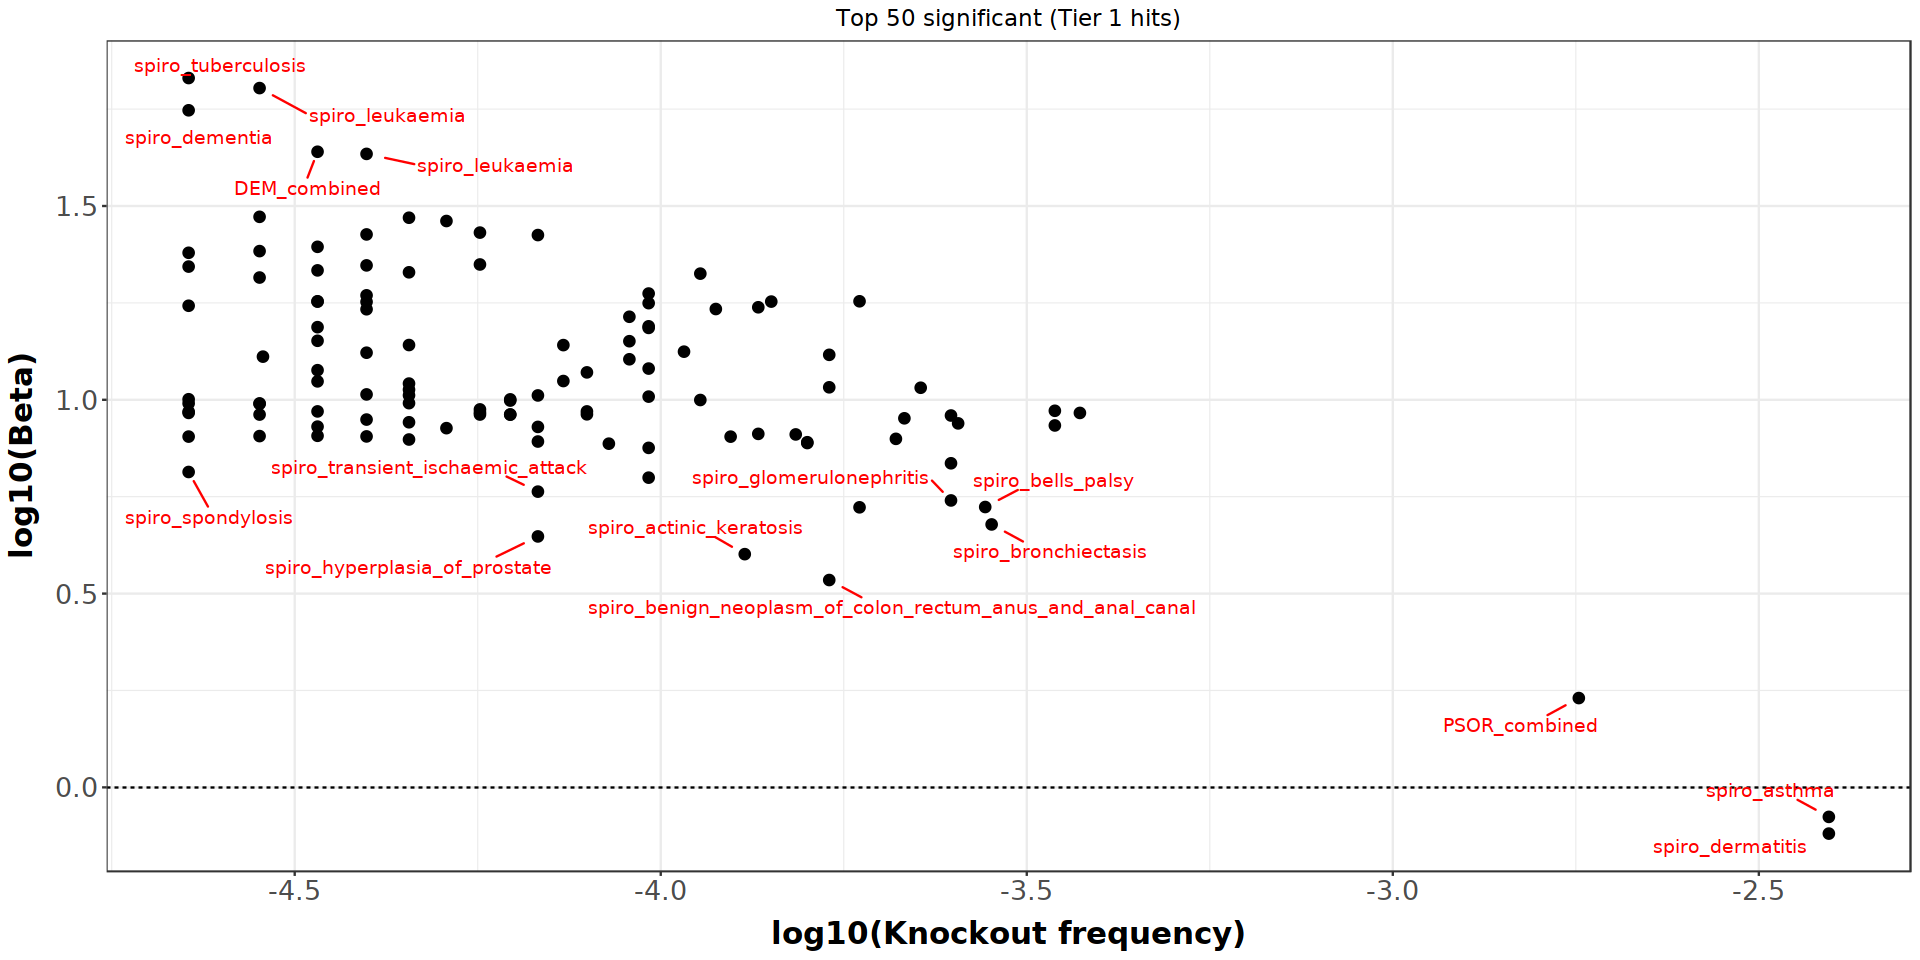

In [11]:
#options(repr.matrix.max.cols=1000, repr.matrix.max.rows=500)
options(repr.plot.width=16, repr.plot.height=8)
d_order <- d_order[d_order$AC_Allele2>=8,]
d_order <- d_order[d_order$N_case_hom>=2,]
#d_order <- d_order[1:50, ]
ggplot(d_order, aes(x=log10(d_order$AF_Allele2), y=log10(d_order$BETA), label=phenotype)) +
    geom_point(size = 2.5) +
    geom_hline(yintercept = 0, linetype = 'dashed') +
    geom_text_repel(size = 4, box.padding = 0.75, point.padding = 1.5, max.overlaps = 10, color = 'red') + 
    xlab("log10(Knockout frequency)") +
    ylab("log10(Beta)") +
    ggtitle("Top 50 significant (Tier 1 hits)") +
    theme_bw() +
    theme(
        legend.position = "bottom",
        strip.text = element_text(size=18),
        axis.text=element_text(size=16),
        axis.title=element_text(size=18,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5)
    )
    

In [119]:
list.files(dir)

[1] "220712_pgs_results_bin.png"      "220712_pgs_results_bin.txt.gz"  
 [3] "220712_pgs_results_cts.png"      "220712_pgs_results_cts.txt.gz"  
 [5] "chrom"                           "chrom_qc.pdf"                   
 [7] "intra_chrom_correlation_pgs.png" "ldsc_summary.txt"               
 [9] "ldsc_summary.txt.gz"             "ldsc_summary_qc_passed.txt"     
[11] "pgs_auc_summary.txt.gz"          "pgs_cor_summary.txt.gz"         
[13] "spiro_pgs_auc_summary.txt.gz"

In [205]:
args <- list(
    summary_ldsc = "data/prs/validation/ldsc_summary.txt.gz",
    summary_prs_cts = "data/prs/validation/pgs_cor_summary.txt.gz",
    summary_prs_bin = "data/prs/validation/spiro_pgs_auc_summary.txt.gz",
    bin_header = 'data/phenotypes/dec22_phenotypes_binary_200k_header.tsv',
    cts_header = 'data/phenotypes/filtered_phenotypes_cts_manual.tsv',
    icd = "data/phenotypes/phenotype_icd_chapter.txt"
)

In [206]:
ldsc <- fread(args$summary_ldsc)
cts <- fread(args$summary_prs_cts)
bin <- fread(args$summary_prs_bin)
icd <- fread(args$icd)

In [140]:
binary_header <- readLines(args$bin_header)
binary_header <- binary_header[!grepl("primary_care", binary_header)]
cts_header <- paste0(readLines(args$cts_header),"_int")

In [141]:
colnames(ldsc) <- paste0("ldsc_",colnames(ldsc))
#table(ldsc$ldsc_phenotype)

In [142]:
colnames(ldsc)[colnames(ldsc) == "ldsc_phenotype"] <- "phenotype"

In [143]:
# why is this only 37? These all have very low case count. I think we might have exluded them.
#length(unique(ldsc[ldsc$phenotype %in% binary_header]$phenotype))
#binary_header[!binary_header %in% ldsc[ldsc$phenotype %in% binary_header]$phenotype]

In [144]:
cutoff <- 0.05 / length(binary_header)

In [145]:
res_bin <- merge(ldsc, bin, all.x = TRUE)
res_bin <- res_bin[res_bin$phenotype %in% binary_header,]
res_cts <- merge(ldsc, cts, all.x = TRUE)
res_cts <- res_cts[res_cts$phenotype %in% cts_header,]

In [151]:
res_bin

phenotype,ldsc_estimate,ldsc_std_error,ldsc_zstat,ldsc_pvalue,ldsc_n_snps,ldsc_coef,ldsc_n,ldsc_n_eff,auc_mean,auc_2_5_pct,auc_97_5_pct,auc_sd,pred_cases,pred_controls,pred_n,included
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<chr>
AD_combined,0.99780687,0.007213132,138.3319775,0.000000e+00,1165296,intercept,246152,6200.454,0.6842644,0.6654818,0.7028937,0.009560054,925,162771,163696,No
AD_combined,0.15850344,0.078630619,2.0157980,4.382110e-02,1165296,h2,246152,6200.454,0.6842644,0.6654818,0.7028937,0.009560054,925,162771,163696,No
BC_combined,1.00558734,0.008437621,119.1790062,0.000000e+00,1165296,intercept,246152,42128.429,0.5848428,0.5783061,0.5914852,0.003342826,7419,156277,163696,Yes
BC_combined,0.12842434,0.019621011,6.5452459,5.939756e-11,1165296,h2,246152,42128.429,0.5848428,0.5783061,0.5914852,0.003342826,7419,156277,163696,Yes
CAD_combined,1.02365501,0.008286864,123.5274339,0.000000e+00,1165296,intercept,246108,108933.862,0.5810288,0.5766489,0.5853436,0.002222721,18254,145414,163668,Yes
CAD_combined,0.12138802,0.008822503,13.7589097,4.502663e-43,1165296,h2,246108,108933.862,0.5810288,0.5766489,0.5853436,0.002222721,18254,145414,163668,Yes
CC_combined,1.00478087,0.006806072,147.6300580,0.000000e+00,1165296,intercept,246152,20544.447,0.5545400,0.5447115,0.5645389,0.004994939,3323,160373,163696,Yes
CC_combined,0.13295696,0.028340776,4.6913662,2.713867e-06,1165296,h2,246152,20544.447,0.5545400,0.5447115,0.5645389,0.004994939,3323,160373,163696,Yes
CD_combined,1.00337453,0.007354835,136.4238067,0.000000e+00,1165296,intercept,246152,6232.047,0.5462510,0.5275238,0.5647558,0.009497943,944,162752,163696,No


In [146]:
res_subset_bin <- res_bin[res_bin$ldsc_coef == "h2",]
res_subset_bin$pass_qc <- res_subset_bin$ldsc_pvalue < cutoff # 1e-5
res_subset_bin_phenos_pass <- res_subset_bin$phenotype[res_subset_bin$pass_qc]
res_subset_bin_phenos_pass <- as.character(res_subset_bin_phenos_pass)

In [147]:
res_bin$included <- ifelse(res_bin$phenotype %in% res_subset_bin_phenos_pass, 'Yes', "No")

In [148]:
# rename phenotypes
#res_bin$phenotype <- gsub("_combined","", res_bin$phenotype)

In [149]:
# setup color scale
my_colors <- c("grey","#65B8EF") #"#4DBBD5B2")
names(my_colors) <- c("No","Yes")

fill_scale <- scale_fill_manual(name = "Used downstream", values = my_colors)
color_scale <- scale_color_manual(name = "Used downstream", values = my_colors)

phenotype,ldsc_estimate,ldsc_std_error,ldsc_zstat,ldsc_pvalue,ldsc_n_snps,ldsc_coef,ldsc_n,ldsc_n_eff,auc_mean,auc_2_5_pct,auc_97_5_pct,auc_sd,pred_cases,pred_controls,pred_n,included
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<chr>
AD_combined,0.99780687,0.007213132,138.3319775,0.000000e+00,1165296,intercept,246152,6200.454,0.6842644,0.6654818,0.7028937,0.009560054,925,162771,163696,No
AD_combined,0.15850344,0.078630619,2.0157980,4.382110e-02,1165296,h2,246152,6200.454,0.6842644,0.6654818,0.7028937,0.009560054,925,162771,163696,No
BC_combined,1.00558734,0.008437621,119.1790062,0.000000e+00,1165296,intercept,246152,42128.429,0.5848428,0.5783061,0.5914852,0.003342826,7419,156277,163696,Yes
BC_combined,0.12842434,0.019621011,6.5452459,5.939756e-11,1165296,h2,246152,42128.429,0.5848428,0.5783061,0.5914852,0.003342826,7419,156277,163696,Yes
CAD_combined,1.02365501,0.008286864,123.5274339,0.000000e+00,1165296,intercept,246108,108933.862,0.5810288,0.5766489,0.5853436,0.002222721,18254,145414,163668,Yes
CAD_combined,0.12138802,0.008822503,13.7589097,4.502663e-43,1165296,h2,246108,108933.862,0.5810288,0.5766489,0.5853436,0.002222721,18254,145414,163668,Yes
CC_combined,1.00478087,0.006806072,147.6300580,0.000000e+00,1165296,intercept,246152,20544.447,0.5545400,0.5447115,0.5645389,0.004994939,3323,160373,163696,Yes
CC_combined,0.13295696,0.028340776,4.6913662,2.713867e-06,1165296,h2,246152,20544.447,0.5545400,0.5447115,0.5645389,0.004994939,3323,160373,163696,Yes
CD_combined,1.00337453,0.007354835,136.4238067,0.000000e+00,1165296,intercept,246152,6232.047,0.5462510,0.5275238,0.5647558,0.009497943,944,162752,163696,No


In [133]:
res_order <- res_bin[res_bin$ldsc_coef == "h2"]
levels <- res_order$phenotype[order(res_order$ldsc_pvalue)]
res_bin$phenotype <- factor(res_bin$phenotype, levels = levels)

In [134]:
options(repr.matrix.max.rows=100, repr.matrix.max.cols=30)
#res_bin
length(unique(res_bin$phenotype))

[1] 293

In [38]:
pvalues <- res_bin[res_bin$ldsc_coef == "h2",]$ldsc_pvalue
sum(pvalues < 0.001)

[1] 87

In [51]:
res_bin <- res_bin[res_bin$ldsc_pvalue < 0.001, ]

In [52]:
res_bin <- res_bin[is.na(res_bin$auc_mean)]

In [53]:
point_size = 0.75

p1 <- ggplot(res_bin[res_bin$ldsc_coef == "h2",], 
       aes(
           y=phenotype, #reorder(phenotype, ldsc_estimate),
           x=ldsc_estimate, 
           xmax=ldsc_estimate+ldsc_std_error,
           xmin=ldsc_estimate-ldsc_std_error,
           color=included
           )
      ) + 
    geom_pointrange(size = point_size) +
    xlab(expression("LDSC" ~h^2)) + 
    ylab("Phenotypes") +
    theme_bw() +
    scale_x_continuous(breaks=scales::pretty_breaks(n=5)) +
    coord_cartesian(xlim=c(0, 1)) +
    color_scale +
    theme(
        axis.text=element_text(size=14),
        axis.title=element_text(size=14,face="bold"),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
        legend.position="none"
    ) + guides(color="none")

p2 <- ggplot(res_bin[res_bin$ldsc_coef == "intercept",], 
       aes(
           y=phenotype,
           x=ldsc_estimate, 
           xmax=ldsc_estimate+ldsc_std_error,
           xmin=ldsc_estimate-ldsc_std_error,
           color=included
           )
      ) + 
    theme_bw() +
    geom_pointrange(size = point_size) +
    xlab(expression("LDSC intercept")) + 
    geom_vline(xintercept = 1, linetype = 'dashed') +
    scale_x_continuous(breaks=scales::pretty_breaks(n=3)) + 
    color_scale +
    theme(axis.title.y=element_blank(),
        axis.text.y=element_blank(),
        axis.ticks.y=element_blank(),
        strip.text = element_text(size=16),
        axis.text=element_text(size=14),
        axis.title=element_text(size=14,face="bold"),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
        legend.position="none"
    ) + guides(color="none")

p3 <- ggplot(res_bin[res_bin$ldsc_coef == "h2",], 
       aes(
           y=phenotype, #y=reorder(phenotype, ldsc_estimate),
           x=-log10(ldsc_pvalue),
           xmax=-log10(ldsc_pvalue),
           xmin=-log10(ldsc_pvalue),
           color=included
           )
      ) + 
    geom_pointrange(size = point_size) +
    xlab(expression("LDSC"~log[10]*"(P-value)")) +
    geom_vline(xintercept = -log10(1e-5), linetype = 'dashed') +
    theme_bw() +
    color_scale +
    scale_x_continuous(breaks=scales::pretty_breaks(n=5)) +
    theme(axis.title.y=element_blank(),
        axis.text.y=element_blank(),
        axis.ticks.y=element_blank(),
        strip.text = element_text(size=16),
        axis.text=element_text(size=14),
        axis.title=element_text(size=14,face="bold"),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
        legend.position="none"
    ) + guides(color="none")

p4 <- ggplot(res_bin, 
       aes(
           y=phenotype, #y=reorder(phenotype, ldsc_estimate),
           x=auc_mean,
           xmax=auc_2_5_pct,
           xmin=auc_97_5_pct,
           color=included
           )
      ) + 
    geom_pointrange(size = point_size) +
    theme_bw() +
    color_scale +
    geom_vline(xintercept = 0.5, linetype = 'dashed') +
    xlab(expression("AUROC (95% CI)")) + 
    ylab("Phenotypes") +
    scale_x_continuous(breaks=scales::pretty_breaks(n=4)) +
    theme(axis.title.y=element_blank(),
        axis.text.y=element_blank(),
        axis.ticks.y=element_blank(),
        strip.text = element_text(size=16),
        axis.text=element_text(size=14),
        axis.title=element_text(size=14,face="bold"),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
        legend.position="none"
    ) + guides(color="none")

Warning message:
"Removed 197 rows containing missing values (geom_pointrange)."


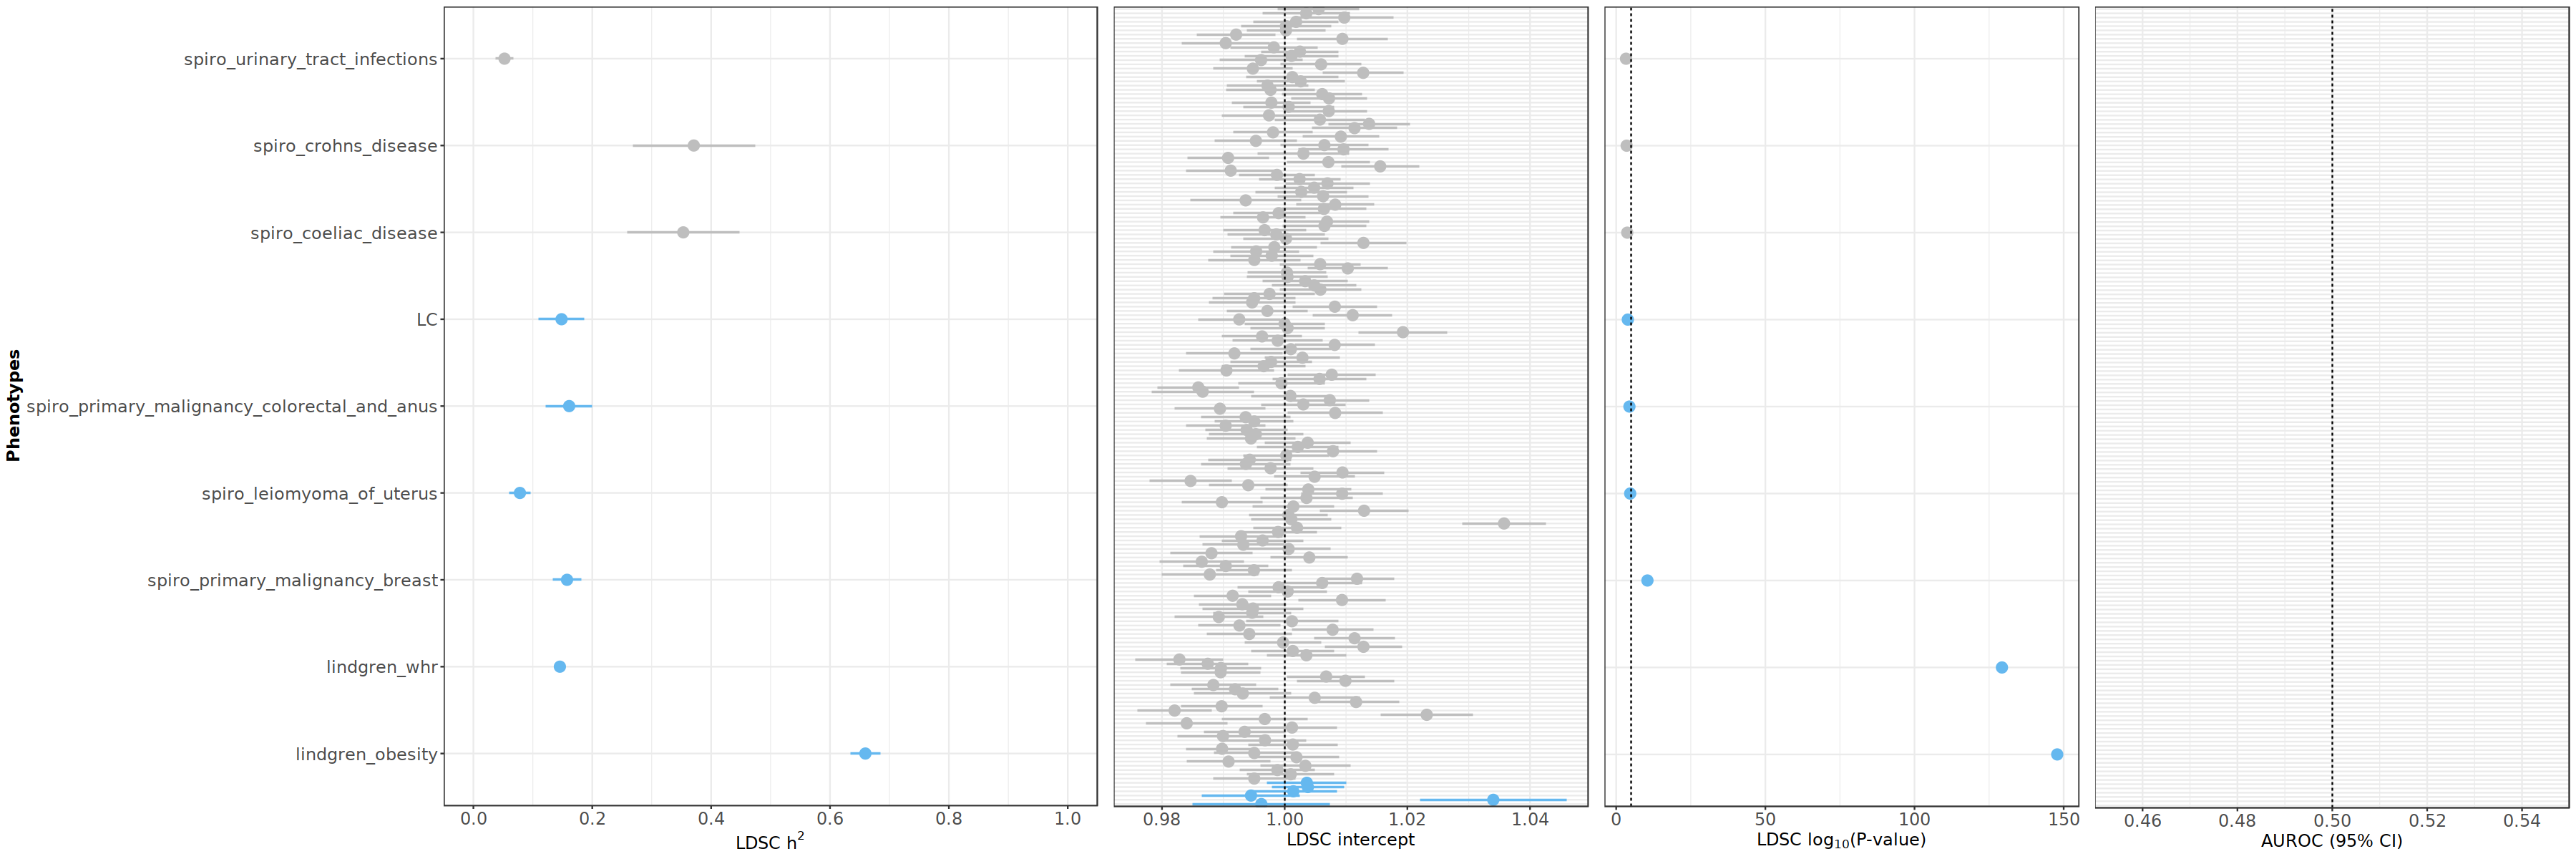

In [54]:
#ggsave("derived/plots/220908_ldpred_ldsc_summary_combined.pdf", width = 13, height = 8)
options(repr.plot.width=30, repr.plot.height=10)
cowplot::plot_grid(p1, p2, p3, p4, rel_widths = (c(0.45, 0.2, 0.2, 0.2)), ncol = 4, nrow = 1)

In [18]:
# Note, that PKD_combined is not shown because the estimate goes beyond the borders.

# Manhatten plots

In [3]:
setwd("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb")
devtools::load_all("utils/modules/R/gwastools")
devtools::load_all("utils/modules/R/prstools")
require(ggplot2)
require(ggrepel)
require(tidyverse)
require(data.table)

i Loading gwastools

! Adding files missing in collate: /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/gwastools/R/which_overlap.R

i Loading PRStools

Loading required package: bigsnpr

Loading required package: bigassertr

Loading required package: tidyverse

-- Attaching packages ---------------------------------------------------------------------------------------------------------------------- tidyverse 1.3.1 --

v tibble  3.1.5     v purrr   0.3.4
v tidyr   1.1.4     v dplyr   1.0.7
v readr   1.4.0     v forcats 0.5.1

-- Conflicts ------------------------------------------------------------------------------------------------------------------------- tidyverse_conflicts() --
x dplyr::between()   masks data.table::between()
x dplyr::filter()    masks stats::filter()
x dplyr::first()     masks data.table::first()
x dplyr::lag()       masks stats::lag()
x dplyr::last()      masks data.table::last()
x purrr::transpose() masks data.tabl

In [4]:
get_qq_df <- function(files){
    ribbon_p <- 0.95
    d <- do.call(rbind, lapply(files, function(f){
        stopifnot(file.exists(f))
        #print(f)
        d <- fread(f)
        d <- d[d$AC_Allele2>=8,]
        #d <- d[d$N_case_hom>=2,]
        #KC <- d$AC_Allele2 / 2
        #KF <- d$AF_Allele2
        #case_KC <- d$N_case_hom / 2
        #ctrl_KC <- d$N_ctrl_hom / 2
        if (is.numeric(d$p.value)){
            if (nrow(d) > 0){
                # read from conditional analysis if present
                if ("p.value_c" %in% colnames(d)) {
                    d$p.value <- d$p.value_c
                }
                d$p.value.expt <- get_expected_p(d$p.value, na.rm = TRUE)
                n <- length(d$p.value)
                # create QQ
                dt <- data.table(
                    ensembl_gene_id = d$MarkerID[order(d$p.value)],
                    pvalue = sort(d$p.value),
                    pvalue.observed = -log10(sort(d$p.value)),
                    pvalue.expected = -log10(sort(d$p.value.expt)),
                    clower = -log10(qbeta(p = (1 - ribbon_p) / 2, shape2 = n:1, shape1 = 1:n)),
                    cupper = -log10(qbeta(p = (1 + ribbon_p) / 2, shape2 = n:1, shape1 = 1:n)),
                    #ko_cases = d$N_case_hom[order(d$p.value)]/2,
                    #kc = d$AC_Allele2[order(d$p.value)]/2
                )
                # regex the current phenotype and clean
                dt$prs <- ifelse(grepl("locoprs", f),"With PRS", "Without PRS")
                dt$analysis <- basename(f)
                dt$analysis <- stringr::str_extract(dt$analysis, "200k_.+pLoF_damaging_missense")
                dt$analysis <- gsub("200k_", "", dt$analysis)
                dt$analysis <- gsub("_pLoF_damaging_missense", "", dt$analysis)

                # add hgnc and grch38 position
                dt$hgnc_symbol <- ensembl_to_hgnc[dt$ensembl_gene_id]
                dt$contig <- ensembl_to_contig[dt$ensembl_gene_id]
                dt$pos <- ensembl_to_pos[dt$ensembl_gene_id]
                #dt$KC_case <- case_KC
                #dt$KC_ctrl <- ctrl_KC
                #dt$KF <- kc$

                # plot label if deviated from null
                dt$label <- NA 
                bool <- dt$pvalue.observed >= dt$clower & dt$pvalue.observed > 3
                dt$label[bool] <- dt$hgnc_symbol[bool]


            return(dt)
            } else {
                return(NULL)
            }
        } else {
            write(paste0(f, "was excluded because p-value col was invalid."), stdout())   
        }
    }))
    return(d)
}

In [5]:
get_formatted_df <- function(files){
    ribbon_p <- 0.95
    d <- do.call(rbind, lapply(files, function(f){
        stopifnot(file.exists(f))
        #print(f)
        d <- fread(f)
        if (is.numeric(d$p.value)){
            if (nrow(d) > 0){
                # read from conditional analysis if present
                if ("p.value_c" %in% colnames(d)) {
                    d$p.value <- d$p.value_c
                    d$p.value.NA <- d$p.value.NA_c
                    d$BETA <- d$BETA_c
                    d$SE <- d$SE_c
                    d$Tstat <- d$Tstat_c
                    d$var <- d$var_c
                }
                d$p.value <- as.numeric(d$p.value)
                d$p.value.NA <- as.numeric(d$p.value.NA)
                d$BETA <- as.numeric(d$BETA)
                d$SE <- as.numeric(d$SE)
                
                d$ensembl_gene_id <- d$MarkerID
                d$ensembl_gene_id[!grepl("ENSG", d$ensembl_gene_id)] <- NA
                d$pvalue = d$p.value
                d$prs <- ifelse(grepl("locoprs", f),"With PRS", "Without PRS")
                d$analysis <- basename(f)
                d$analysis <- stringr::str_extract(d$analysis, "200k_.+pLoF_damaging_missense")
                d$analysis <- gsub("200k_", "", d$analysis)
                d$analysis <- gsub("_pLoF_damaging_missense", "", d$analysis)
                d$phenotype <- d$analysis
                
                # add hgnc and grch38 position
                d$hgnc_symbol <- ensembl_to_hgnc[d$ensembl_gene_id]
                d$contig <- ensembl_to_contig[d$ensembl_gene_id]
                d$pos <- ensembl_to_pos[d$ensembl_gene_id]
                d$N_ko_case <- unlist(ifelse("N_ko_case" %in% colnames(d), list(d$N_case_hom), NA))
                d$N_ko_ctrl <- unlist(ifelse("N_ko_ctrl" %in% colnames(d), list(d$N_ctrl_hom), NA))
                d$N_ko <- d$AC_Allele2/2
                d$KF_ko <- d$AF_Allele2
                d$KF_case <- d$AF_case
                d$KF_ctrl <- d$AF_ctrl
                
                # plot label if deviated from null
                d$label <- NA 
                bool <- d$pvalue.observed >= d$clower & d$pvalue.observed > 3
                d$label[bool] <- d$hgnc_symbol[bool]


            return(d)
            } else {
                return(NULL)
            }
        } else {
            write(paste0(f, "was excluded because p-value col was invalid."), stdout())   
        }
    }))
    return(d)
}

In [6]:
# get all files we need to iterate over
files <- list(
    files_none_no_prs = list_files_saige(cond = "none", prs = "exclude"),
    files_none_prs = list_files_saige(cond = "none", prs = "only"),
    files_common_no_prs = list_files_saige(cond = "common", prs = "exclude"),
    files_common_prs = list_files_saige(cond = "common", prs = "only"),
    files_rare_no_prs = list_files_saige(cond = "rare", prs = "exclude"),
    files_rare_prs = list_files_saige(cond = "rare", prs = "only"),
    files_combined_prs = list_files_saige(cond = "combined", prs = "only"),
    files_combined_no_prs = list_files_saige(cond = "combined", prs = "exclude")
)


#files <- list(
#    files_none = list_files_saige(cond = "none", prs = "exclude"),
#    files_common = list_files_saige(cond = "common", prs = "exclude"),
#    files_rare = list_files_saige(cond = "rare", prs = "exclude"),
#    files_combined = list_files_saige(cond = "combined", prs = "only")
#)

header <- fread("data/phenotypes/dec22_phenotypes_binary_200k_header.tsv", header = FALSE)$V1
head(header)

[1] "BC_combined"   "CAD_combined"  "COPD_combined" "CLD_combined" 
[5] "CC_combined"   "DEM_combined"

In [10]:
sig_p <- 0.05 / (320 * 5000)

In [11]:
selected_files <- list_files_saige(cond = "none", prs = "exclude")
ds1 <- get_formatted_df(selected_files)

/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/saige/output/binary/step2/min_mac4/ukb_eur_wes_200k_spiro_undescended_testicle_pLoF_damaging_missense.txt.gzwas excluded because p-value col was invalid.


In [12]:
selected_files <- list_files_saige(cond = "none", prs = "prefer")
ds2 <- get_formatted_df(selected_files)

/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/saige/output/binary/step2/min_mac4/ukb_eur_wes_200k_spiro_undescended_testicle_pLoF_damaging_missense.txt.gzwas excluded because p-value col was invalid.
/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/saige/output/binary/step2/min_mac4/ukb_eur_wes_200k_spiro_hiv_pLoF_damaging_missense_locoprs.txt.gzwas excluded because p-value col was invalid.


In [13]:
selected_files <- list_files_saige(cond = "common", prs = "prefer")
ds3 <- get_formatted_df(selected_files)

In [14]:
selected_files <- list_files_saige(cond = "combined", prs = "prefer")
ds4 <- get_formatted_df(selected_files)

In [15]:
common <- fread("data/post_hoc/results/aggr_cond_markers.common.txt.gz")
rare <- fread("data/post_hoc/results/aggr_cond_markers.rare.txt.gz")

In [16]:
d1 <- ds1[ds1$phenotype == pheno,]
d2 <- ds2[ds2$phenotype == pheno,]
d3 <- ds3[ds3$phenotype == pheno,]
d4 <- ds4[ds4$phenotype == pheno,]

stopifnot(all(na.omit(d4$p.value == d4$p.value_c)))
stopifnot(all(na.omit(d3$p.value == d3$p.value_c)))
d3 <- d3[]

In [17]:
common_cond <- common[common$traits == pheno, ]
d3 <- d3[d3$ensembl_gene_id %in% common_cond$genes,]
rare_cond <- rare[rare$phenotype == pheno, ]
d4 <- d4[d4$ensembl_gene_id %in% rare$ensembl_gene_id,]

In [18]:
# get overview of anything is signficant across analyses
s1 <- d1[d1$p.value < sig_p,]
s2 <- d2[d2$p.value < sig_p,]
s3 <- d3[d3$p.value < sig_p,]
s4 <- d4[d4$p.value < sig_p,]
g1234 <- unique(c(s1$ensembl_gene_id, s2$ensembl_gene_id, s3$ensembl_gene_id)) # s4$ensembl_gene_id))

In [19]:
s1 <- s1[s1$ensembl_gene_id %in% g1234,]
s2 <- s2[s2$ensembl_gene_id %in% g1234,]
s3 <- s3[s3$ensembl_gene_id %in% g1234,]
s4 <- s4[s4$ensembl_gene_id %in% g1234,]

In [26]:
s1$conditional <- "none"
s2$conditional <- "prs"
s3$conditional <- "prs+common"
s4$conditional <- "prs+common+rare"

In [27]:
rbind(s1, s2, s3, s4)

ERROR: Error in rbindlist(l, use.names, fill, idcol): Item 3 has 41 columns, inconsistent with item 1 which has 39 columns. To fill missing columns use fill=TRUE.


In [27]:
sig_t <- 0.05 / (320 * 5000)
analysis_names <- names(files)
lst_all_genes <- lapply(analysis_names, function(name){
    selected_files <- files[[name]]
    ds <- get_formatted_df(selected_files)
    ds <- ds[ds$p.value < sig_t,]
    ds$name <- name
    ds
    return(ds)
})

/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/saige/output/binary/step2/min_mac4/ukb_eur_wes_200k_spiro_undescended_testicle_pLoF_damaging_missense.txt.gzwas excluded because p-value col was invalid.


In [35]:
analysis_names

[1] "files_none"     "files_common"   "files_rare"     "files_combined"

In [34]:
sig_genes <- lapply(lst_all_genes, function(x) length(unique(x)))
sig_genes

[[1]]
[1] 605

[[2]]
[1] 25

[[3]]
[1] 1899

[[4]]
[1] 250

In [306]:


cols_to_keep <- c("phenotype","contig","ensembl_gene_id", "hgnc_symbol", 
                  "N_ko","N_ko_case","N_ko_ctrl", 
                  "KF_ko", "KF_case", "KF_ctrl", 
                  "BETA", "SE", "Tstat", "var", "p.value")

lapply(analysis_names, function(name){
    print(name)
    selected_files <- files[[name]]
    ds <- get_formatted_df(selected_files[1:2])
    
    #print(name)
    #print(head(ds))
    #ds <- ds[,..cols_to_keep]
    ds <- ds[ds$p.value < sig_t,]
    #ds <- ds[ds$phenotype %in% header,]
    #ds$analysis <- name
    genes <- unique(ds$ensembl_gene_id)
    return(genes)
    
})







[1] "files_none_no_prs"
[1] "files_none_prs"
[1] "files_common_no_prs"


Warning message in set(x, j = name, value = value):
"Column 'N_ko_case' does not exist to remove"
Warning message in set(x, j = name, value = value):
"Column 'N_ko_ctrl' does not exist to remove"
Warning message in set(x, j = name, value = value):
"Column 'N_ko_case' does not exist to remove"
Warning message in set(x, j = name, value = value):
"Column 'N_ko_ctrl' does not exist to remove"


[1] "files_common_prs"


Warning message in set(x, j = name, value = value):
"Column 'N_ko_case' does not exist to remove"
Warning message in set(x, j = name, value = value):
"Column 'N_ko_ctrl' does not exist to remove"
Warning message in set(x, j = name, value = value):
"Column 'N_ko_case' does not exist to remove"
Warning message in set(x, j = name, value = value):
"Column 'N_ko_ctrl' does not exist to remove"


[1] "files_rare_no_prs"


...

[1] "files_combined_prs"


Warning message in set(x, j = name, value = value):
"Column 'N_ko_case' does not exist to remove"
Warning message in set(x, j = name, value = value):
"Column 'N_ko_ctrl' does not exist to remove"
Warning message in set(x, j = name, value = value):
"Column 'N_ko_case' does not exist to remove"
Warning message in set(x, j = name, value = value):
"Column 'N_ko_ctrl' does not exist to remove"


[1] "files_combined_no_prs"


Warning message in set(x, j = name, value = value):
"Column 'N_ko_case' does not exist to remove"
Warning message in set(x, j = name, value = value):
"Column 'N_ko_ctrl' does not exist to remove"
Warning message in set(x, j = name, value = value):
"Column 'N_ko_case' does not exist to remove"
Warning message in set(x, j = name, value = value):
"Column 'N_ko_ctrl' does not exist to remove"


[[1]]
[1] "ENSG00000162438" "ENSG00000163012" "ENSG00000118777" "ENSG00000184465"
[5] "ENSG00000181333" "ENSG00000184613" "ENSG00000171446" "ENSG00000128310"

[[2]]
 [1] "ENSG00000162438" "ENSG00000163012" "ENSG00000118777" "ENSG00000184465"
 [5] "ENSG00000181333" "ENSG00000184613" "ENSG00000171446" "ENSG00000128310"
 [9] "ENSG00000132781" "ENSG00000183495"

[[3]]
[1] "ENSG00000137225" "ENSG00000203734" "ENSG00000213676" "ENSG00000241404"
[5] "ENSG00000121957" "ENSG00000135870" "ENSG00000142621"

[[4]]
[1] "ENSG00000121957" "ENSG00000135870" "ENSG00000142621"

[[5]]
  [1] "ENSG00000162438"                    
  [2] "chr1:944707:G:C"                    
  [3] "chr1:1332061:G:A"                   
  [4] "chr1:1454439:C:T"                   
  [5] "chr1:1627432:AC:A"                  
  [6] "chr1:3510867:G:A"                   
  [7] "chr1:8337933:G:A"                   
  [8] "chr1:8339613:C:T"                   
  [9] "chr1:9582449:T:A"                   
 [10] "chr1:9982450:A:G"                   
 [11] "chr1:11274008:C:G"                  
 [12] "chr1:11967042:T:A"                  
 [13] "chr1:16049204:C:T"                  
 [14] "chr1:16992342:G:A"                  
 [15] "chr1:20721898:T:A"                  
 [16] "chr1:22659578:C:T"                  
 [17] "chr1:24075318:C:T"                  
 [18] "chr1:24929843:G:C"                  
 [19] "chr1:25809081:G:A"                  
 [20] "chr1:26201379:C:G"                  
 [21] "chr1:27006419:G:A"                  
 [22] "chr1:27332074:A:T"                  
 [23] "chr1:27361204:C:CG"                 
 [24] "chr1:27370902:C:T"                  
 [25] "chr1:27394198:C:T"                  
 [26] "chr1:27616920:C:T"                  
 [27] "chr1:29065037:T:G"                  
 [28] "chr1:31585156:T:C"                  
 [29] "chr1:34757363:TG:T"                 
 [30] "chr1:36322319:GGT:G"                
 [31] "chr1:40835017:C:T"                  
 [32] "chr1:41510971:CCT:C"                
 [33] "chr1:42205796:G:A"                  
 [34] "chr1:42929951:A:C"                  
 [35] "chr1:43956696:C:G"                  
 [36] "chr1:44001436:G:C"                  
 [37] "chr1:44785145:G:A"                  
 [38] "chr1:44826923:T:G"                  
 [39] "chr1:44941601:A:T"                  
 [40] "chr1:45332795:G:A"                  
 [41] "chr1:46195887:G:C"                  
 [42] "chr1:46510613:A:G"                  
 [43] "chr1:46613210:G:A"                  
 [44] "chr1:47144356:G:C"                  
 [45] "chr1:53078582:C:T"                  
 [46] "chr1:53220260:C:A"                  
 [47] "chr1:56917593:C:A"                  
 [48] "chr1:75878990:A:C"                  
 [49] "chr1:77579547:C:A"                  
 [50] "chr1:85164699:T:C"                  
 [51] "chr1:89063086:C:T"                  
 [52] "chr1:100068142:C:T"                 
 [53] "chr1:109629394:C:T"                 
 [54] "chr1:110518334:G:C"                 
 [55] "chr1:113857744:C:G"                 
 [56] "chr1:114568245:A:G"                 
 [57] "chr1:114680440:G:A"                 
 [58] "chr1:151780124:CCTGT:C"             
 [59] "chr1:151801272:T:C"                 
 [60] "chr1:155200539:G:C"                 
 [61] "chr1:155254397:TACC:T"              
 [62] "chr1:155285301:C:T"                 
 [63] "chr1:156068280:G:T"                 
 [64] "chr1:156156480:T:C"                 
 [65] "chr1:156161384:G:T"                 
 [66] "chr1:156384597:G:A"                 
 [67] "chr1:158181535:G:GC"                
 [68] "chr1:160173686:C:T"                 
 [69] "chr1:160419401:C:A"                 
 [70] "chr1:168096538:TG:T"                
 [71] "chr1:169878818:T:G"                 
 [72] "chr1:172665823:A:G"                 
 [73] "chr1:186386004:CA:C"                
 [74] "chr1:197142340:T:A"                 
 [75] "chr1:197328691:T:G"                 
 [76] "chr1:201135748:C:A"                 
 [77] "chr1:205586146:G:A"                 
 [78] "chr1:212329195:T:C"             

phenotype,contig,ensembl_gene_id,hgnc_symbol,N_ko,N_ko_case,N_ko_ctrl,KF_ko,KF_case,KF_ctrl,BETA,SE,Tstat,var,p.value
<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AD_combined,1,ENSG00000162438,CTRC,3,1,2,1.69888e-05,0.000988142,1.13911e-05,16.0882,2.88124,1.93797,0.1204590,2.353685e-08
AD_combined,2,ENSG00000163012,ZSWIM2,3,1,2,1.69888e-05,0.000988142,1.13911e-05,49.6583,5.00811,1.97991,0.0398706,3.561880e-23
AD_combined,4,ENSG00000118777,ABCG2,3,1,2,1.69888e-05,0.000988142,1.13911e-05,18.3998,3.07487,1.94608,0.1057660,2.178083e-09
AD_combined,6,ENSG00000184465,WDR27,4,1,3,2.26517e-05,0.000988142,1.70867e-05,29.5937,3.87923,1.96657,0.0664522,2.370214e-14
AD_combined,11,ENSG00000181333,HEPHL1,4,1,3,2.26517e-05,0.000988142,1.70867e-05,24.6716,3.54795,1.95994,0.0794412,3.556591e-12
AD_combined,12,ENSG00000184613,NELL2,3,1,2,1.69888e-05,0.000988142,1.13911e-05,28.3839,3.80078,1.96484,0.0692235,8.147592e-14
AD_combined,17,ENSG00000171446,KRT27,5,1,4,2.83147e-05,0.000988142,2.27823e-05,36.9606,4.32800,1.97317,0.0533858,1.343549e-17
AD_combined,22,ENSG00000128310,GALR3,7,1,6,3.96405e-05,0.000988142,3.41734e-05,17.4349,2.99491,1.94379,0.1114890,5.832325e-09


In [253]:
colnames(ds)

[1] "CHR"             "POS"             "MarkerID"        "Allele1"        
 [5] "Allele2"         "AC_Allele2"      "AF_Allele2"      "MissingRate"    
 [9] "BETA"            "SE"              "Tstat"           "var"            
[13] "p.value"         "p.value.NA"      "Is.SPA"          "AF_case"        
[17] "AF_ctrl"         "N_case"          "N_ctrl"          "N_case_hom"     
[21] "N_case_het"      "N_ctrl_hom"      "N_ctrl_het"      "ensembl_gene_id"
[25] "pvalue"          "prs"             "analysis"        "phenotype"      
[29] "hgnc_symbol"     "contig"          "pos"             "N_ko_case"      
[33] "N_ko_ctrl"       "N_ko"            "KF_ko"           "KF_case"        
[37] "KF_crtl"         "label"

In [234]:
f <- list_files_saige(cond = "combined", prs = "include")
f[grepl("CC", f)]

[1] "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/saige/output/binary/step2_rare_cond/min_mac4/ukb_eur_wes_200k_CC_combined_pLoF_damaging_missense_locoprs.txt.gz"

In [181]:
no_prs <- get_analysis_stats_df(files)

In [182]:
with_prs <- get_analysis_stats_df(files_prs)

data/saige/output/binary/step2/min_mac4/ukb_eur_wes_200k_spiro_hiv_pLoF_damaging_missense_locoprs.txt.gzwas excluded because p-value col was invalid.


[1] 129

In [179]:
stopifnot(any(!no_prs$prs))

In [178]:
any(no_prs$prs)

[1] FALSE

In [147]:
all_of_them <- rbind(no_prs, with_prs)

In [151]:
m_vars <- c("inflation","inflation_KC0_5", "inflation_KC5_10", "inflation_KC10_20","inflation_KC20_30", "inflation_KC30")
i_vars <- c("analysis","prs")
melted_dt <- reshape2::melt(all_of_them, measure.vars = m_vars, id.vars = i_vars)
melted_dt$variable <- factor(melted_dt$variable, levels = m_vars)

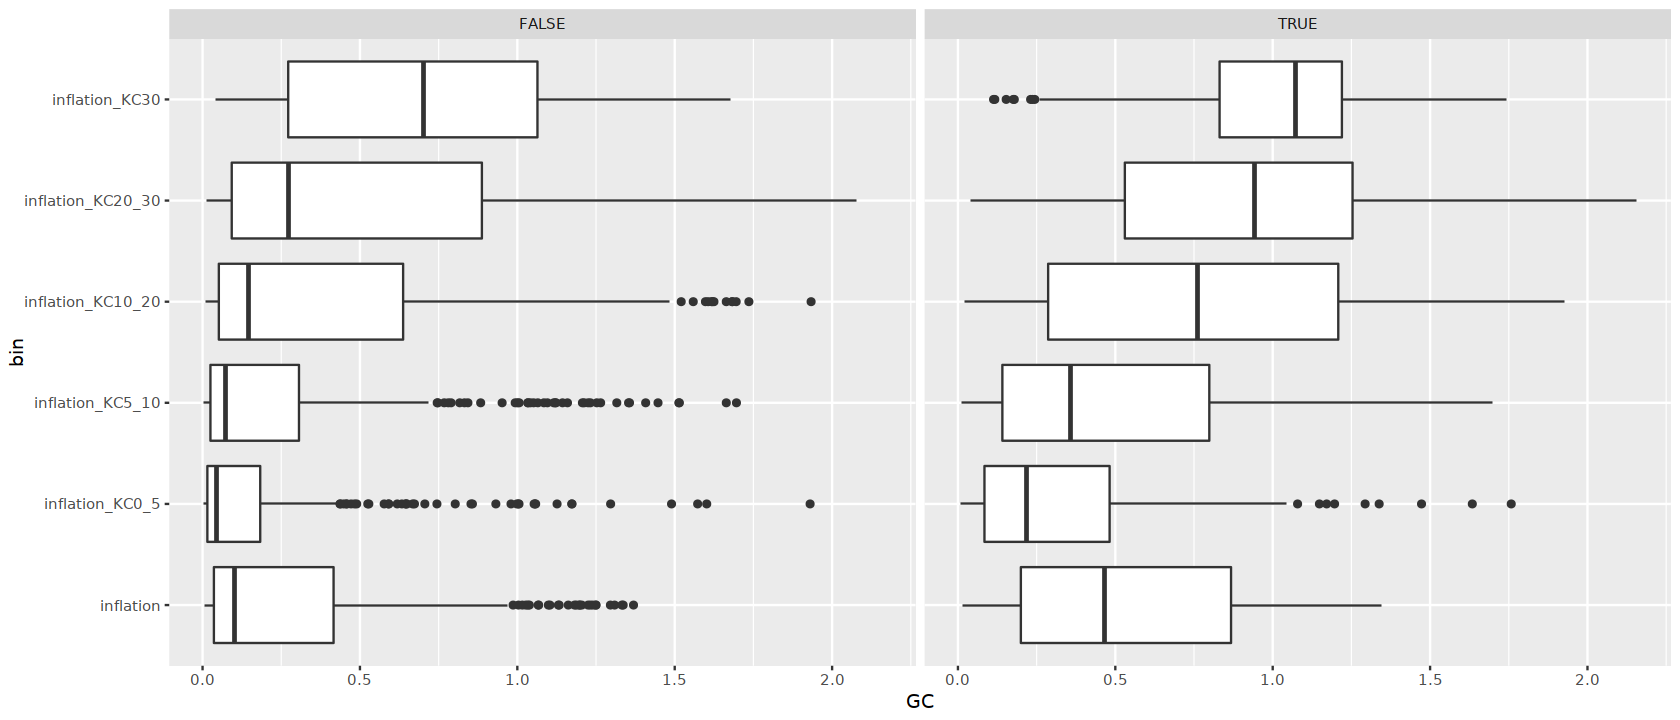

In [155]:
options(repr.plot.width=14, repr.plot.height=6)
ggplot(melted_dt, aes(y=variable, x=value)) +
    geom_boxplot() +
    xlab("GC") +
    ylab("bin") +
    facet_wrap(~prs)

In [ ]:
header <- fread("data/phenotypes/dec22_phenotypes_binary_200k_header.tsv", header = FALSE)$V1
targets <- paste0("ukb_eur_wes_200k_",header, "_pLoF_damaging_missense.txt.gz", sep = "")
targets_prs <- paste0("ukb_eur_wes_200k_",header, "_pLoF_damaging_missense_locoprs.txt.gz", sep = "")
directory <- "data/saige/output/binary/step2_common/"
files <- file.path(directory, targets)
files_prs <- file.path(directory, targets_prs)
files_prs <- unlist(lapply(files_prs, function(f) f[file.exists(f)]))

In [ ]:
files

In [ ]:
#d <- fread("data/saige/output/binary/step2/min_mac4/ukb_eur_wes_200k_spiro_hiv_pLoF_damaging_missense_locoprs.txt.gz")
#d$p.value <- as.numeric(d$p.value)
#d[d$p.value == 0,]

In [161]:
header <- fread("data/phenotypes/dec22_phenotypes_binary_200k_header.tsv", header = FALSE)$V1
targets <- paste0("ukb_eur_wes_200k_",header, "_pLoF_damaging_missense.txt.gz", sep = "")
targets_prs <- paste0("ukb_eur_wes_200k_",header, "_pLoF_damaging_missense_locoprs.txt.gz", sep = "")
directory <- "data/saige/output/binary/step2/min_mac4"
files <- file.path(directory, targets)
files_prs <- file.path(directory, targets_prs)
files_prs <- unlist(lapply(files_prs, function(f) f[file.exists(f)]))

In [162]:
d1 <- get_formatted_df(files)
d1$analysis <- factor(d1$analysis, levels = unique(d1$analysis))
d2 <- get_formatted_df(files_prs)
d2$analysis <- factor(d2$analysis, levels = unique(d2$analysis))

data/saige/output/binary/step2/min_mac4/ukb_eur_wes_200k_spiro_hiv_pLoF_damaging_missense_locoprs.txt.gzwas excluded because p-value col was invalid.


In [163]:
icd <- fread("data/phenotypes/phenotype_icd_chapter.txt")
d <- rbind(d1, d2)
d <- merge(icd, d, by.x = "unix_code", by.y = "analysis", all.x = TRUE)
d$analysis <- d$unix_code

In [171]:
test <- d
test <- test[test$hgnc_symbol == "CHEK2",]
calc_inflation(test$p.value)

[1] 0.1327706

In [164]:
# helper for getting gene start/end
get_start_and_end <- function(chr_lengths) {
    start <- rep(0, length(chr_lengths))
    start[1] <- 1
    end <- rep(0, length(chr_lengths))
    end[1] <- chr_lengths[1]
    for(chr in 2:length(chr_lengths)) {
        start[chr] <- start[chr-1] + chr_lengths[chr-1]
        end[chr] <- end[chr-1] + chr_lengths[chr]
    }
    return(list(start=start, end=end))
}

# lengths for chromosome
chr_lengths_38 <- c(248956422, 242193529, 198295559,190214555,181538259,170805979,159345973,
    145138636,138394717,133797422,135086622,133275309,114364328,107043718,101991189,90338345,
    83257441,80373285,58617616,64444167,46709983,50818468,156040895)
contigs_ <- c(1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23)

# thresholds for plotting
buffer <- 100000000
significance_T <- 0.05 / (4000 * 320)

In [67]:
# get hits that pass our sig thresholds
sig_table <- as.data.frame(table(d$pvalue < significance_T, d$analysis))
sig_table <- sig_table[sig_table$Var1 == TRUE, ]
sig_table <- sig_table[,c(2,3)]
colnames(sig_table) <- c("phenotype", "hits")

# summarize hits in vector
sig_phenos <- as.character(unique(sig_table$phenotype[sig_table$hits > 0]))
not_sig_phenos <- as.character(unique(sig_table$phenotype[sig_table$hits == 0]))
n_sig <- length(sig_phenos)

In [68]:
# make labels in italics


In [102]:
# only plot things that are exome wide significnat
dt <- d
dt <- dt[dt$analysis %in% sig_phenos,]

dt <- dt[dt$AC_Allele2 >= 8, ]


#dt <- dt[dt$pvalue < 0.0001,]
dt$label <- dt$hgnc_symbol #paste0("italic('",dt$hgnc_symbol,"')~1")
dt$label[dt$pvalue > significance_T] <- NA
dt <- dt[dt$prs == "With PRS",]
nrow(dt)

[1] 6595

In [103]:
# add to data.frame
#all_categories <- unique(categories)
#n_categories <- length(all_categories)
dt$categories <- dt$ICD_chapter #categories[dt$analysis]

dt$colors <- dt$categories
#dt$colors[dt$pvalue > significance_T ] <- ""

In [104]:
#colfunc<-colorRampPalette(c("#2266AC", "#65B8EF",,"tomato2","tomato3"))#))
#plot(rep(1,20),col=(colfunc(20)), pch=19,cex=2)

In [105]:
# setup color scale
#my_colors <- c(rev(RColorBrewer::brewer.pal(n_categories, "Dark2")), "grey")
#my_colors <- unique(c(RColorBrewer::brewer.pal(11, "RdBu"), RColorBrewer::brewer.pal(8, "Dark2")))
#names(my_colors) <- c(all_categories, "")
#fill_scale <- scale_fill_manual(name = "Group", values = my_colors)
#color_scale <- scale_color_manual(name = "Group", values = my_colors)

In [116]:
contigs <- dt$contig
positions <- dt$pos
pvals <- dt$pvalue
labels <- dt$label
phenotypes <- dt$analysis
colors <- dt$colors
n_ko_case <- dt$N_ko_case
facets <- dt$ICD_chapter_desc
c(contigs[1],positions[1],pvals[1],labels[1],phenotypes[1],colors[1], n_ko_case[1], facets[1])

[1] "1"                                          
[2] "171198967.5"                                
[3] "0.984123"                                   
[4] NA                                           
[5] "AD_combined"                                
[6] "F"                                          
[7] "1009"                                       
[8] "Mental, behavioural, and neurodevelopmental"

In [107]:
# get contigs
start_end <- get_start_and_end(chr_lengths_38)
dt_contigs <- data.frame(contig=contigs_, start=start_end$start, end=start_end$end) %>%
mutate(middle = floor(start + (end-start)/2),
       length = (end-start)) %>%
mutate(shifted_position=middle + (contig - 1) * buffer)

In [108]:
length(contigs)
length(positions)
length(pvals)
length(labels)
length(phenotypes)
length(colors)
length(n_ko_case)
length(facets)

[1] 6595

[1] 6595

[1] 6595

[1] 6595

[1] 6595

[1] 6595

[1] 6595

In [117]:
# setup plotting
dt_plot <- data.frame(
    contig=contigs, 
    position=as.integer(positions), 
    pval=as.numeric(pvals), 
    labels=labels,
    phenotype=phenotypes,
    colors = colors,
    n_ko_case = as.integer(n_ko_case),
    facets
) %>% mutate(
        x = dt_contigs[gsub('X', '23', contig), 'start'] + position + (as.integer(gsub('X', '23', contig))-1)*buffer,
        y = pvals
)


In [110]:
options(repr.matrix.max.cols=50, repr.matrix.max.rows=100)


Warning message:
"Removed 16 rows containing missing values (geom_point)."
Warning message:
"Removed 6524 rows containing missing values (geom_text_repel)."


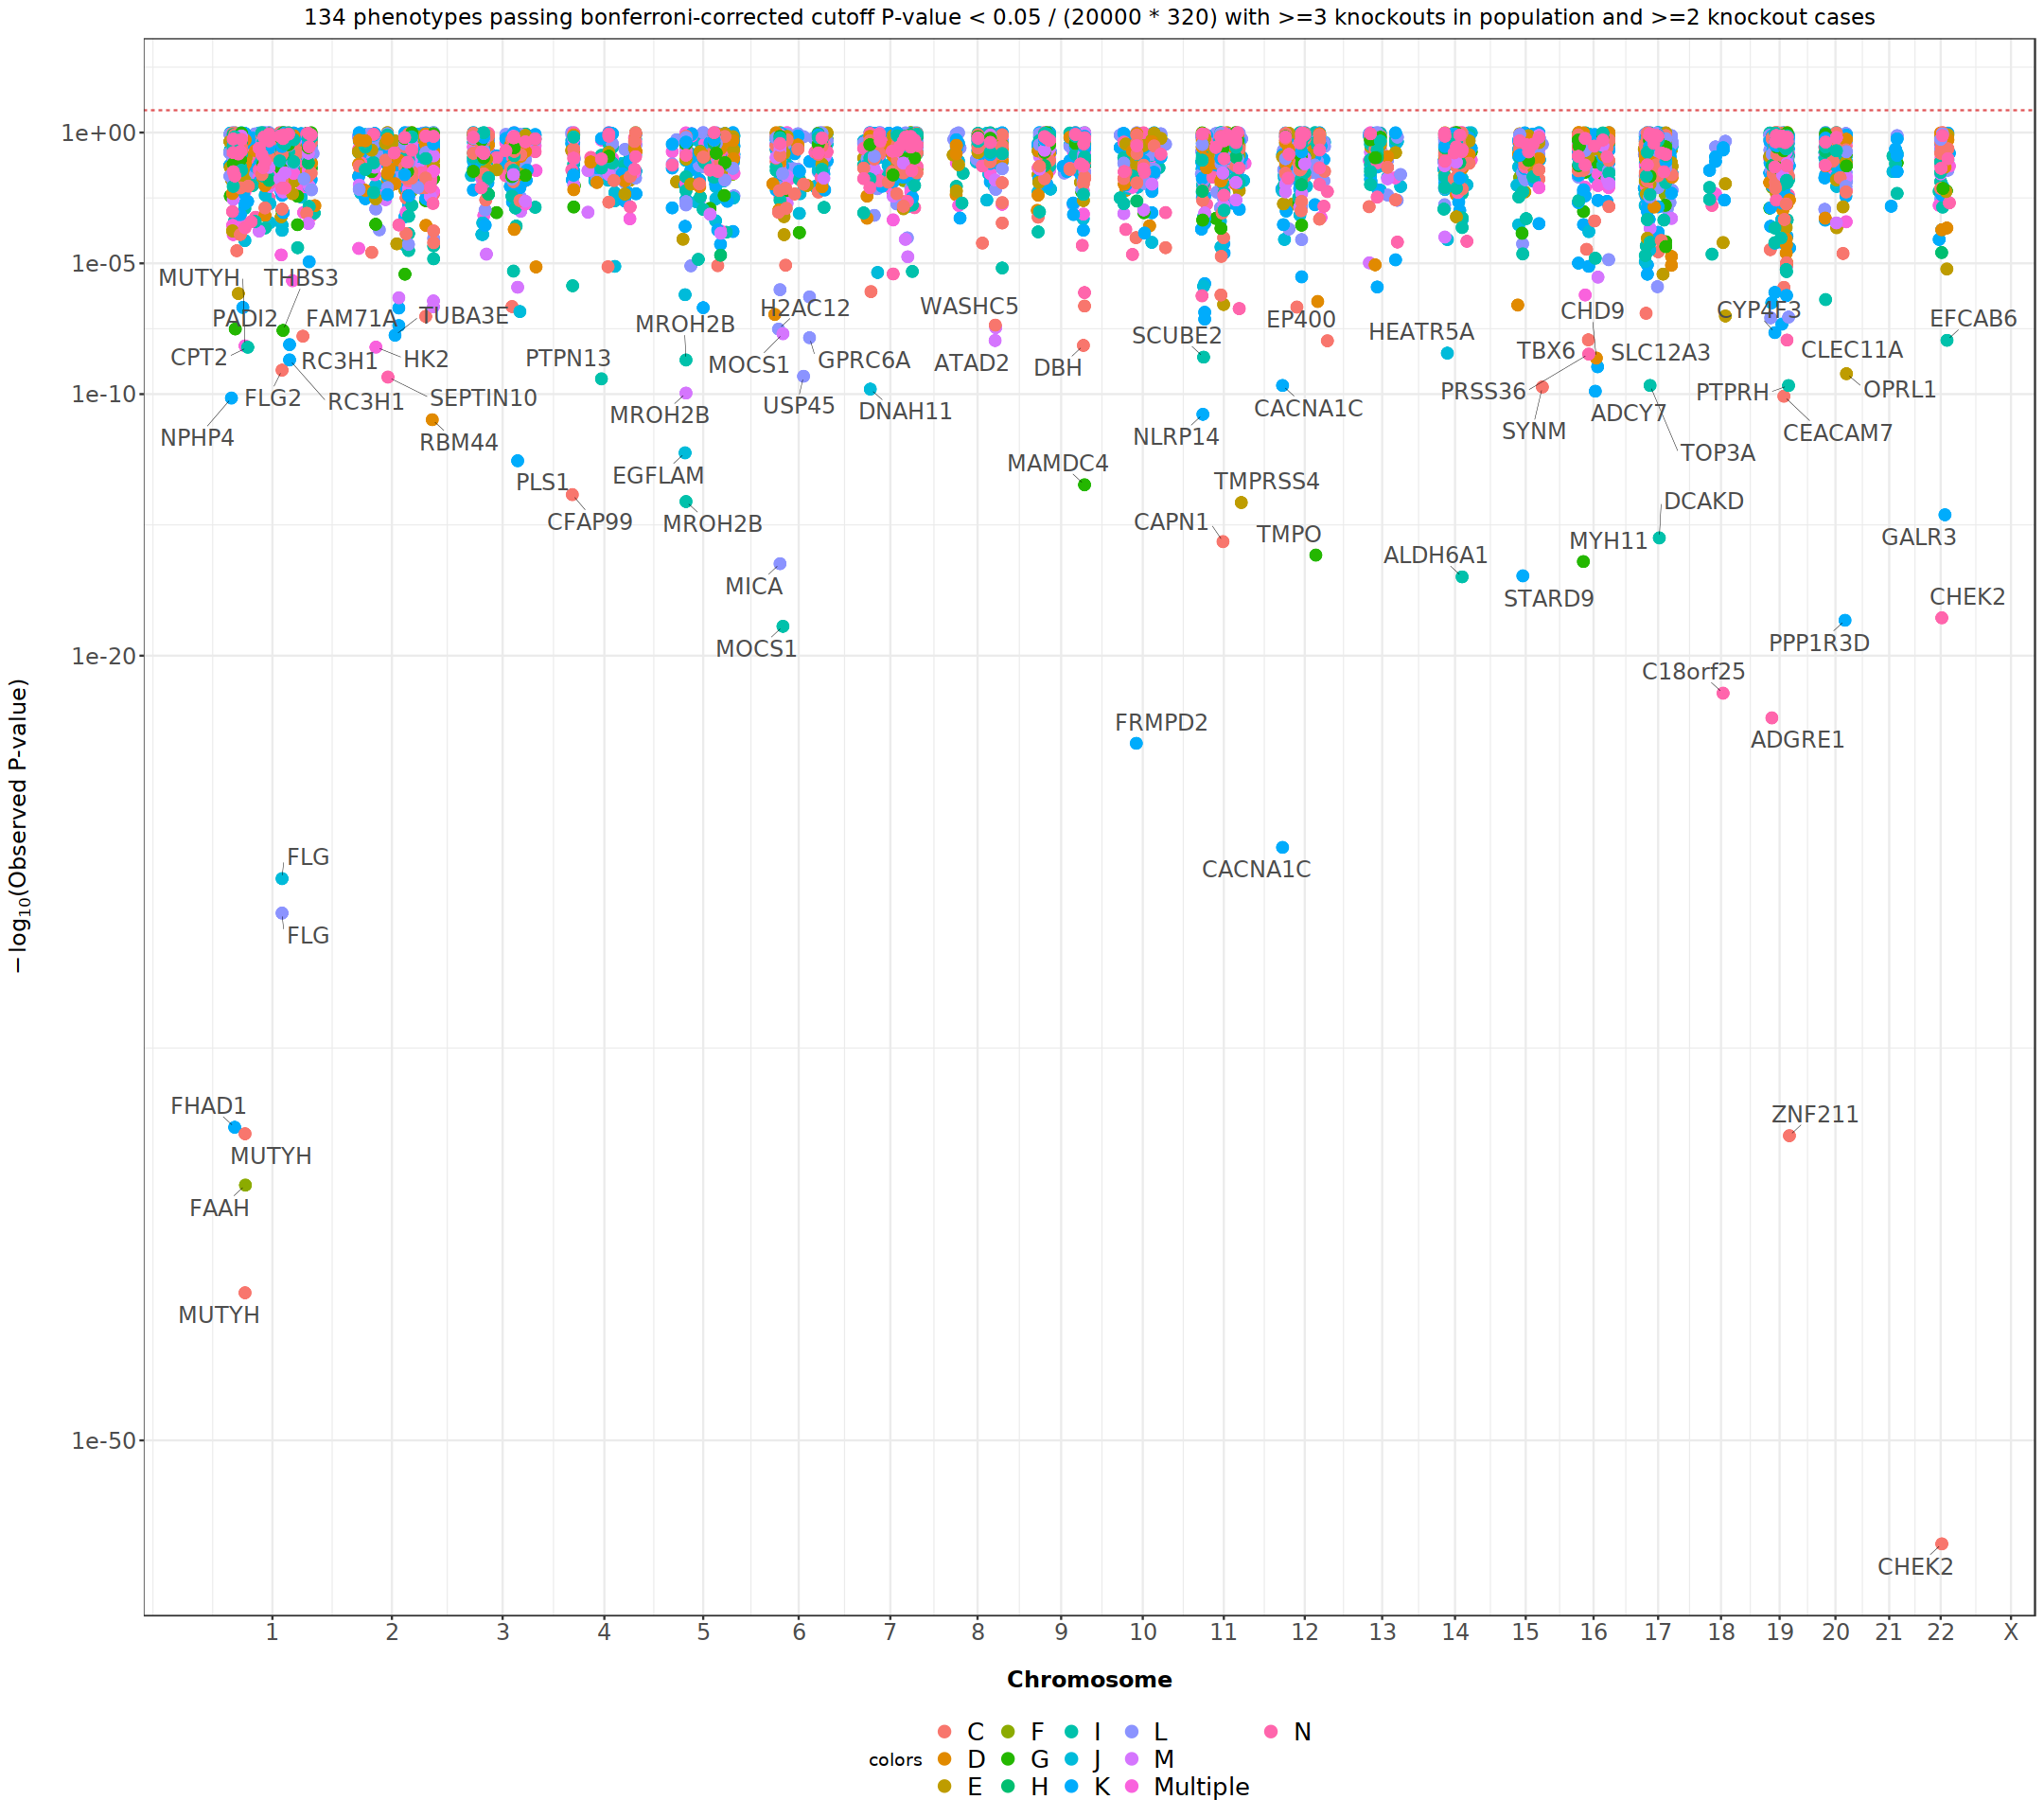

In [121]:
options(repr.plot.width=18, repr.plot.height=16)
p <- ggplot(dt_plot, aes(x=x,y=y,label=labels, color=colors)) + 
    geom_point_rast(size = 3) +
    #color_scale +
    geom_hline(yintercept=-log10(significance_T), color='#E15759', linetype='dashed') +
    scale_x_continuous(breaks=dt_contigs$shifted_position, labels=gsub(23, 'X', dt_contigs$contig)) +
    #scale_y_continuous(breaks=scales::pretty_breaks(n=10)) +
    scale_y_continuous(trans = 'log10', breaks=c(1, 1e-5, 1e-10, 1e-20, 1e-50)) +  
    geom_text_repel(
        box.padding = 0.5, point.padding = 0.2,
        color = 'grey30', segment.color = 'black', max.overlaps=Inf,
        size=5, segment.size=0.1, show.legend = FALSE, fontface = "italic"
    ) +
    xlab("Chromosome") +
    ylab(expression(paste(-log[10],'(Observed P-value)' ))) +
    theme_bw() +
    theme(
        axis.text=element_text(size=14),
        axis.title=element_text(size=14,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=16)),
        axis.title.y = element_text(margin=ggplot2::margin(r=16)),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
        legend.position="bottom",
        legend.text=element_text(size=15)
    ) +
    #facet_wrap(~facets) +
    ggtitle(paste0(n_sig," phenotypes passing bonferroni-corrected cutoff P-value < 0.05 / (20000 * 320) with >=3 knockouts in population and >=2 knockout cases"))

p

In [85]:
test <- dt[dt$hgnc_symbol == "USP45",]
test <- test[order(test$p.value),]
test

unix_code,phenotype,ICD_chapter,ICD_chapter_desc,CHR,POS,MarkerID,Allele1,Allele2,AC_Allele2,AF_Allele2,MissingRate,BETA,SE,Tstat,var,p.value,p.value.NA,Is.SPA,AF_case,AF_ctrl,N_case,N_ctrl,N_case_hom,N_case_het,N_ctrl_hom,N_ctrl_het,ensembl_gene_id,pvalue,prs,hgnc_symbol,contig,pos,N_ko_case,N_ko,label,analysis,categories,colors
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>
spiro_actinic_keratosis,Actinic keratosis,L,Skin and subcutaneous tissue,chr6,315,ENSG00000123552,YKxS,EZJD,46,0.000130485,0,4.350710,0.698967,8.90527,2.04686,4.831294e-10,4.831294e-10,FALSE,0.000964134,0.000105214,5186,171080,5,0,18,0,ENSG00000123552,4.831294e-10,With PRS,USP45,6,99477026,5,23,USP45,spiro_actinic_keratosis,L,L
spiro_primary_malignancy_prostate,Primary Malignancy_Prostate,C,Neoplasms,chr6,315,ENSG00000123552,YKxS,EZJD,46,0.000130485,0,3.118190,1.353610,3.41987,1.09675,1.062217e-02,0.001092539,TRUE,0.000672948,0.000121181,2972,173294,2,0,21,0,ENSG00000123552,1.062217e-02,With PRS,USP45,6,99477026,2,23,NA,spiro_primary_malignancy_prostate,C,C
spiro_dermatitis,Dermatitis (atopc/contact/other/unspecified),L,Skin and subcutaneous tissue,chr6,315,ENSG00000123552,YKxS,EZJD,46,0.000130485,0,0.138841,0.350574,1.12968,8.13655,6.920773e-01,0.6920773,FALSE,0.000142837,0.000128814,21003,155263,3,0,20,0,ENSG00000123552,6.920773e-01,With PRS,USP45,6,99477026,3,23,NA,spiro_dermatitis,L,L


In [305]:
icd

phenotype,ICD_chapter,ICD_chapter_desc,unix_code
<chr>,<chr>,<chr>,<chr>
Alzheimers disease,F,"Mental, behavioural, and neurodevelopmental",AD_combined
Cirrhosis,K,Digestive,CIRR_combined
Crohns disease,K,Digestive,CD_combined
depression,F,"Mental, behavioural, and neurodevelopmental",DEP_combined
ectopic pregnancy,O,"Pregnancy, childbirth and the puerperium",EP_combined
IBD,K,Digestive,IBD_combined
NASH,K,Digestive,NASH_combined
oligomenorrhea,N,Genitourinary,OLI_combined
polycystic kidney disease,Q,Congenital,PKD_combined


In [187]:
d <- rbind(d1, d2)

In [188]:
# setup color scale
my_colors <- c("#CC6666","#65B8EF") #c("#7BA98A","#65B8EF")
names(my_colors) <- c("Without PRS", "With PRS")
fill_scale <- scale_fill_manual(name = "prs", values = my_colors)
color_scale <- scale_color_manual(name = "prs", values = my_colors)

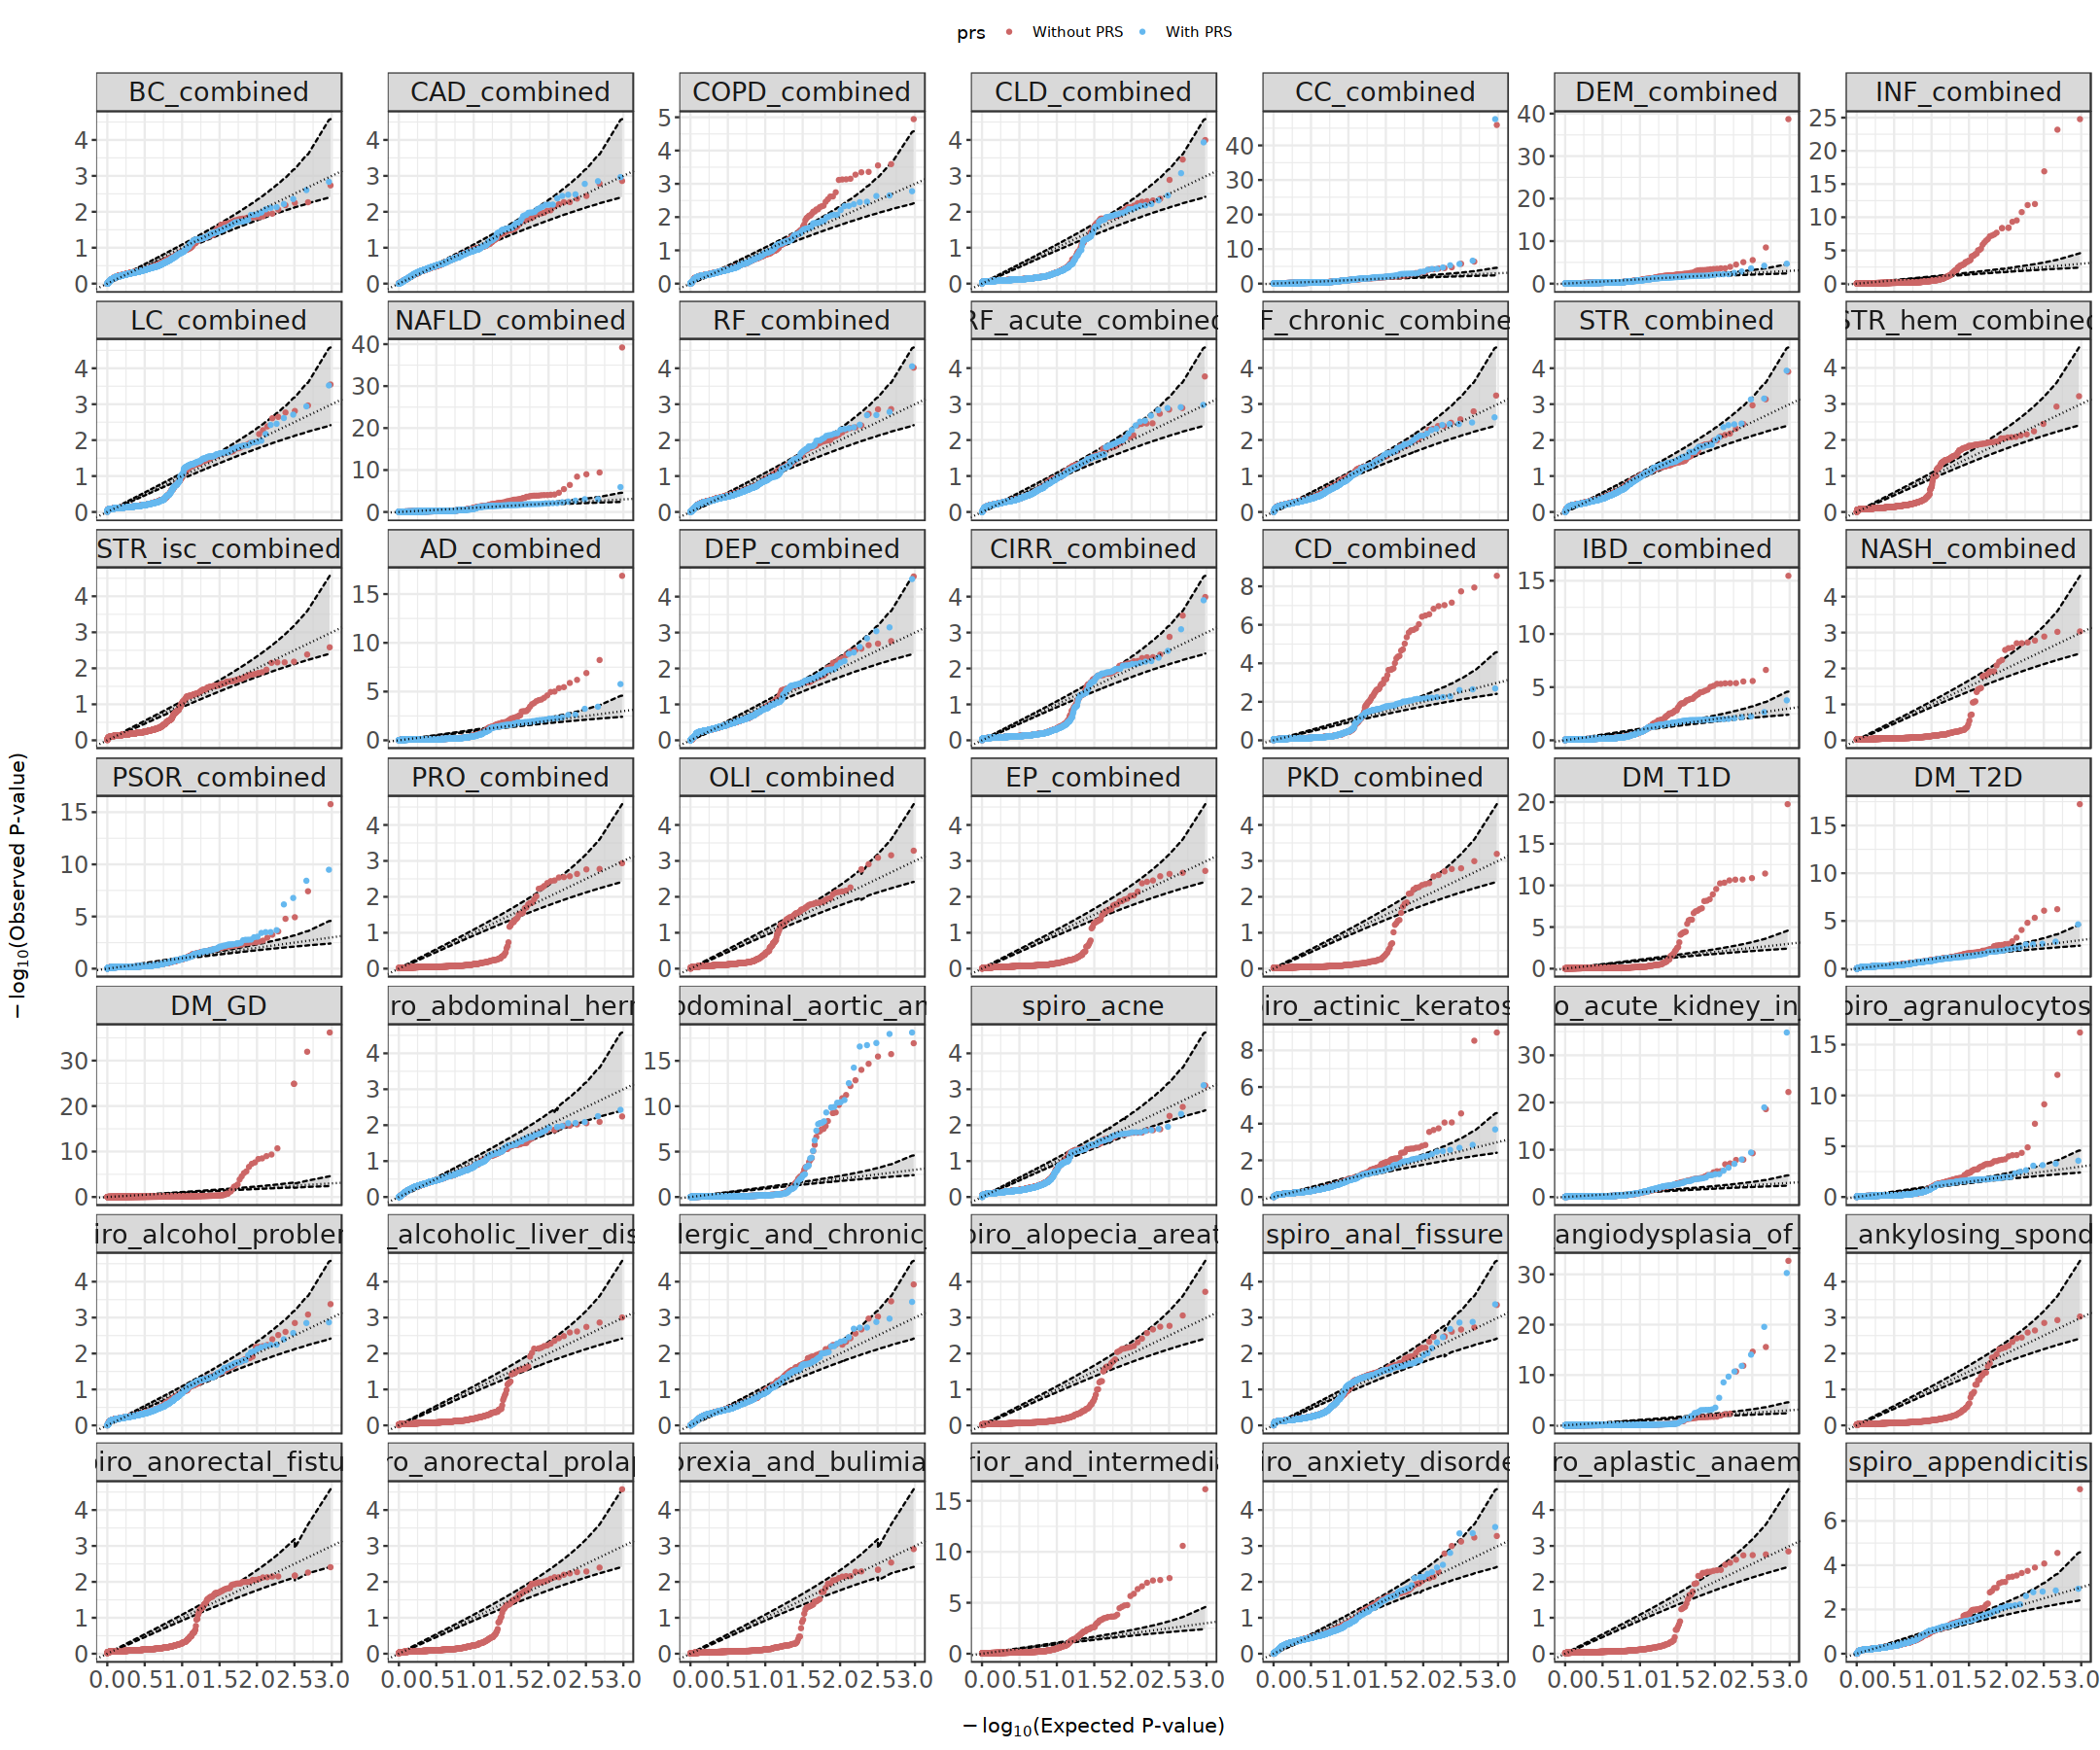

In [189]:
options(repr.plot.width=18, repr.plot.height=15)
ggplot(d, aes(x=pvalue.expected, y=pvalue.observed, ymax=cupper, ymin=clower, label = label, color=prs)) +
    geom_ribbon(fill="grey80", color="black", alpha = 0.7, linetype = 'dashed') +
    geom_point(size = 0.75) +
    geom_abline(linetype = 'dotted') + 
    scale_x_continuous(breaks=scales::pretty_breaks(n=5)) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=5)) +
    xlab(expression(paste(-log[10],'(Expected P-value)' ))) +
    ylab(expression(paste(-log[10],'(Observed P-value)' ))) +
    color_scale +
    #geom_label_repel(
    #    box.padding = 0.4, label.padding=0.1, point.padding = 0.2,
    #    color = 'grey30', segment.color = 'grey50', max.overlaps=Inf,
    #    size=2, segment.size=0.1, show.legend = FALSE
    #) +
    facet_wrap_paginate(~analysis, nrow = 7, ncol = 7, page = 1, scales = "free_y") +
    theme_bw() + 
    theme(
        strip.text = element_text(size=16),
        axis.text=element_text(size=14),
        axis.title=element_text(size=12,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=16)),
        axis.title.y = element_text(margin=ggplot2::margin(r=16)),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
        legend.position="top"
    )

In [190]:
dt <- as.data.table(table(d$analysis, d$prs))
traits_with_prs <- dt$V1[(dt$V2 == "With PRS") & (dt$N != 0)]

In [191]:
d_with_prs <- d[(d$analysis %in% traits_with_prs) & (d$prs == "With PRS"),]
d_without_prs <- d[(!d$analysis %in% traits_with_prs) & (d$prs == "Without PRS"),]
d_final <- rbind(d_with_prs, d_without_prs)

In [35]:
test <- d_final[d_final$pvalue.observed > -log10(0.05 / (315 * 20000)),]
test[rev(order(test$pvalue.observed)),]
#test[test$prs == "With PRS",]

ERROR: Error in eval(expr, envir, enclos): object 'd_final' not found


In [36]:
get_spa_iter <- function(path, verbose = TRUE){
    # path <- "data/conditional/common/spa_iter_new/spa_iter/ukb_eur_wes_200k_PSOR_combined_pLoF_damaging_missense_cond_i2.mrg"
    stopifnot(grepl("i[0-9]", path))
    stopifnot(grepl("mrg", path))
    placeholder <- stringr::str_extract(path, "i[0-9]+")

    # get files that can be read
    splitted <- unlist(strsplit(basename(path), split = placeholder))
    regex <- paste0(splitted[1:2],"i[0-9]+", splitted[2])
    files <- list.files(dirname(path), pattern = regex, full.names = TRUE)
    stopifnot(length(files) > 0)
    if (verbose) write(paste("Loading",length(files),"files."))
    d <- do.call(rbind, lapply(files, function(f){
        d <- fread(f)
        stopifnot(file.exists(f))
        cond <- any(grepl("p.value_c",colnames(d)))
        dout <- d[,1:8, with = FALSE]
        if (cond){
            dout$p.value <- d$p.value_c
        } else {
            dout$p.value <- d$p.value
        }
        dout$iteration <- gsub("i","",stringr::str_extract(f, "i[0-9]+"))
        dout$cond <- cond
        return(dout)
    }))  
    return(d)
}



In [24]:
#kos <- read_ukb_wes_kos('pLoF_damaging_missense')

In [25]:
#d <- fread("data/conditional/common/spa_iter_new/spa_iter/ukb_eur_wes_200k_PSOR_combined_pLoF_damaging_missense_cond_i2.mrg")

In [37]:
args <- list(
    path_genes = "data/conditional/common/intervals/min_mac4/ukb_eur_wes_200k_PSOR_combined_pLoF_damaging_missense.txt.gz",
    path_spa = "data/conditional/common/spa_iter/ukb_eur_wes_200k_PSOR_combined_pLoF_damaging_missense_cond_i1.mrg",
    path_markers = "data/conditional/common/spa_iter/ukb_eur_wes_200k_PSOR_combined_pLoF_damaging_missense_cond.markers"
)

In [38]:
# mapping bridge
bridge <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/biomart/220524_hgnc_ensg_enst_chr_pos.txt.gz")
ensembl_to_hgnc <- bridge$hgnc_symbol
names(ensembl_to_hgnc) <- bridge$ensembl_gene_id

# get exons
exons <- fread("/well/lindgren/flassen/ressources/genesets/genesets/data/biomart/221227_enstid_exon_positions.txt.gz")
exons <- exons[,c("ensembl_transcript_id","ensembl_exon_id","exon_chrom_start", "exon_chrom_end")]

In [40]:
args$path_spa

[1] "data/conditional/common/spa_iter/ukb_eur_wes_200k_PSOR_combined_pLoF_damaging_missense_cond_i1.mrg"

In [138]:
marker_dir <- "data/saige/output/binary//step2_combined//min_mac4"
files  <- list.files(marker_dir, full.names = TRUE, pattern = ".rare.markers.full")
d <- do.call(rbind, lapply(files, function(f){
    d <- fread(f)
    return(d)
}))

In [139]:
d

id,ac,keep_variant_ac,min_mac_filter,hash,keep_variant_ld,perfect_ld_marker,ensembl_gene_id,consequence_category,phenotype,keep
<chr>,<int>,<lgl>,<int>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<lgl>
chr10:70255067:TG:T,1,FALSE,4,c02a70f0,TRUE,NA,ENSG00000148734,damaging_missense,CD_combined,FALSE
chr10:70255211:G:GGGCGCGGGCAGAGGCT,2,FALSE,4,f9ef644f,TRUE,NA,ENSG00000148734,damaging_missense,CD_combined,FALSE
chr10:70255273:G:A,2,FALSE,4,a665fa4e,TRUE,NA,ENSG00000148734,damaging_missense,CD_combined,FALSE
chr10:70255324:T:C,4,TRUE,4,d3f6e30b,TRUE,NA,ENSG00000148734,damaging_missense,CD_combined,TRUE
chr10:70255325:A:C,4,TRUE,4,0bbda889,TRUE,NA,ENSG00000148734,damaging_missense,CD_combined,TRUE
chr10:70255361:G:A,6,TRUE,4,fe8a55a1,TRUE,NA,ENSG00000148734,damaging_missense,CD_combined,TRUE
chr10:70255365:G:T,7,TRUE,4,53490348,TRUE,NA,ENSG00000148734,damaging_missense,CD_combined,TRUE
chr10:70255517:G:A,1,FALSE,4,7ed68f3f,TRUE,NA,ENSG00000148734,damaging_missense,CD_combined,FALSE
chr10:70255585:G:C,3,FALSE,4,c618f087,TRUE,NA,ENSG00000148734,damaging_missense,CD_combined,FALSE


In [108]:


genes <- stringr::str_extract(files, "ENSG[0-9]+")

# get a few stats
stats <- data.table(
    genes = genes,
    traits = traits
)

# open files and extract conditional markers
open_files <- do.call(rbind, lapply(files, function(f){
    d <- fread(f)
    d$converged <- (d$V1<30)
    d <- d[nrow(d),c(1,2,4,5,8,7)]
    colnames(d) <- c("iteration", "current_marker", "last_p","cutoff_p", "converged","conditioning_markers")
    return(d)
}))

# combine the files
final <- cbind(stats, open_files)
final$files <- files

# out
outfile <- paste0(args$out_prefix, ".txt.gz")
fwrite(final, outfile, sep = "\t", na="NA", quote=FALSE)


In [39]:
d <- get_spa_iter(args$path_spa)

ERROR: Error in get_spa_iter(args$path_spa): length(files) > 0 is not TRUE


In [22]:
genes <- fread(args$path_genes)

In [ ]:
d$gene_id <- genes$gene[which_overlap(d$POS, d$POS, genes$start_with_padding, genes$end_with_padding)]

In [ ]:
d$hgnc_symbol <- ensembl_to_hgnc_hgnc[d$gene_id]

In [34]:
markers <- fread(args$path_markers)
colnames(markers) <- c("iteration","cond_marker","origin","pvalue","pvalue_cutoff","trait","cond_markers")

ERROR: Error in fread(args$path_markers): File 'data/conditional/common/spa_iter/ukb_eur_wes_200k_PSOR_combined_pLoF_damaging_missense_cond.markers' does not exist or is non-readable. getwd()=='/gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb'


In [20]:
n_variants <- aggregate(POS ~ gene_id, FUN=length, data = d)
colnames(n_variants) <- c("gene","n_variants")
mrg <- merge(genes, n_variants)
colnames(mrg)[1] <- "gene_id"
mrg <- cbind(hgnc_symbol=ensembl_to_hgnc[mrg$gene], mrg)

ERROR: Error in eval(m$data, parent.frame()): object 'd' not found


In [21]:
mrg

ERROR: Error in eval(expr, envir, enclos): object 'mrg' not found


In [18]:
markers$POS <- stringr::str_extract(markers$cond_marker, ":[0-9]+:")
markers$POS <- as.numeric(gsub("\\:","", markers$POS))
markers$most_close_gene <- genes$gene[which_overlap(markers$POS, markers$POS, genes$start_with_padding, genes$end_with_padding)]

In [19]:
markers

iteration,cond_marker,origin,pvalue,pvalue_cutoff,trait,POS,most_close_gene
<int>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
1,chr6:31351254:G:T,common,7.372464e-198,5e-06,PSOR_combinend,31351254,ENSG00000204520
2,chr6:31249331:CA:C,common,4.664272e-21,5e-06,PSOR_combinend,31249331,ENSG00000204520
3,chr6:31271630:G:T,common,1.689156e-24,5e-06,PSOR_combinend,31271630,ENSG00000204520
4,chr6:31447530:A:G,common,1.109157e-18,5e-06,PSOR_combinend,31447530,ENSG00000204520
5,chr6:31175734:G:A,common,1.332336e-11,5e-06,PSOR_combinend,31175734,ENSG00000204520
6,chr6:31493266:G:A,common,3.680615e-10,5e-06,PSOR_combinend,31493266,ENSG00000204520
7,chr6:31274414:A:G,common,8.795341e-11,5e-06,PSOR_combinend,31274414,ENSG00000204520
8,chr6:31133092:G:A,common,4.125625e-08,5e-06,PSOR_combinend,31133092,ENSG00000204520
9,chr6:31392478:A:C,common,4.371409e-06,5e-06,PSOR_combinend,31392478,ENSG00000204520


In [17]:
markers$cond_markers <- NULL
markers$trait <- "PSOR_combinend"
markers

Warning message in set(x, j = name, value = value):
"Column 'cond_markers' does not exist to remove"


iteration,cond_marker,origin,pvalue,pvalue_cutoff,trait,POS,most_close_gene
<int>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
1,chr6:31351254:G:T,common,7.372464e-198,5e-06,PSOR_combinend,31351254,ENSG00000204520
2,chr6:31249331:CA:C,common,4.664272e-21,5e-06,PSOR_combinend,31249331,ENSG00000204520
3,chr6:31271630:G:T,common,1.689156e-24,5e-06,PSOR_combinend,31271630,ENSG00000204520
4,chr6:31447530:A:G,common,1.109157e-18,5e-06,PSOR_combinend,31447530,ENSG00000204520
5,chr6:31175734:G:A,common,1.332336e-11,5e-06,PSOR_combinend,31175734,ENSG00000204520
6,chr6:31493266:G:A,common,3.680615e-10,5e-06,PSOR_combinend,31493266,ENSG00000204520
7,chr6:31274414:A:G,common,8.795341e-11,5e-06,PSOR_combinend,31274414,ENSG00000204520
8,chr6:31133092:G:A,common,4.125625e-08,5e-06,PSOR_combinend,31133092,ENSG00000204520
9,chr6:31392478:A:C,common,4.371409e-06,5e-06,PSOR_combinend,31392478,ENSG00000204520


In [720]:
#boundary_max <- aggregate(POS ~ cluster , FUN=max, data=d)
#boundary_min <- aggregate(POS ~ cluster , FUN=min, data=d)
#boundary_variants <- aggregate(POS ~ cluster , FUN=length, data=d)
#colnames(boundary_max)[2] <- "upper"
#colnames(boundary_min)[2] <- "lower"
#colnames(boundary_variants)[2] <- "variants"
# combine them all
#full <- Reduce(merge, list(boundary_max, boundary_min, boundary_variants))
#full$ensembl_gene_id <- genes$gene[which_overlap(full$lower, full$upper, genes$start, genes$end)]
#full$hgnc_symbol <- ensembl_to_hgnc[full$ensembl_gene_id]

In [721]:
# append hgnc_symbol
#d$hgnc_symbol <- full$hgnc_symbol[which_overlap(d$POS, d$POS, full$lower, full$upper)]

In [801]:


#genes <- fread(args$genes)
#genes <- genes[genes$contig == "chr6",]
#d$gene <- genes$gene[which_overlap(d$POS, d$POS, genes$start_with_padding, genes$end_with_padding)]

In [802]:
mrg

hgnc_symbol,gene,pvalue,contig,start,end,contig_length,end_with_padding,start_with_padding,start_valid,end_valid,valid_intervals,intervals,n_variants
<chr>,<chr>,<dbl>,<chr>,<int>,<int>,<int>,<int>,<int>,<lgl>,<lgl>,<lgl>,<chr>,<int>
GPRC6A,ENSG00000173612,3.738442e-09,chr6,116792085,116829083,170805979,117829083,115792085,TRUE,TRUE,TRUE,[chr6:115792085-117829083],5816
MICA,ENSG00000204520,3.280960e-10,chr6,31399784,31415315,170805979,32415315,30399784,TRUE,TRUE,TRUE,[chr6:30399784-32415315],16254


In [683]:
# get coordinates used
coord <- fread(args$coordinates)
genes <- fread(args$genes)
genes <- genes[genes$contig == 6,]
# get canonical transcript used
transcripts <- kos[kos$gene_id %in% genes$gene]
transcripts <- transcripts[,c("gene_id","transcript_id")]
transcripts <- transcripts[!duplicated(transcripts)]
genes <- merge(transcripts, genes, by.x = "gene_id", by.y = "gene")
# get subset 
exon_subset <- exons[exons$ensembl_transcript_id %in% genes$transcript_id,]

In [ ]:
options(repr.plot.width=14, repr.plot.height=16)
ggplot(d, aes(x=POS, y=-log10(p.value))) +
    geom_point() +
    #geom_errorbar(data=full, aes(x=lower, xmin=lower, xmax=upper , y = 1)) +
    #geom_errorbar(data=genes, aes(x=start, xmin=start, xmax=end , y = 10), color = 'black', size = 1) +
    #geom_errorbar(data=exon_subset, aes(x=exon_chrom_start, xmin=exon_chrom_start, xmax=exon_chrom_end , y = 1
    #                                    , color=ensembl_exon_id), size = 1) +
    facet_grid(iteration~gene_id, scales='free') #+
    #facet_wrap(~iteration) +
    #xlim(c(116828820, 116793250)) +
    #xlab("Genomic position (Chr6)") +
    #ylab("-log10(P-value)") +
    #ggtitle("Conditional analysis for")

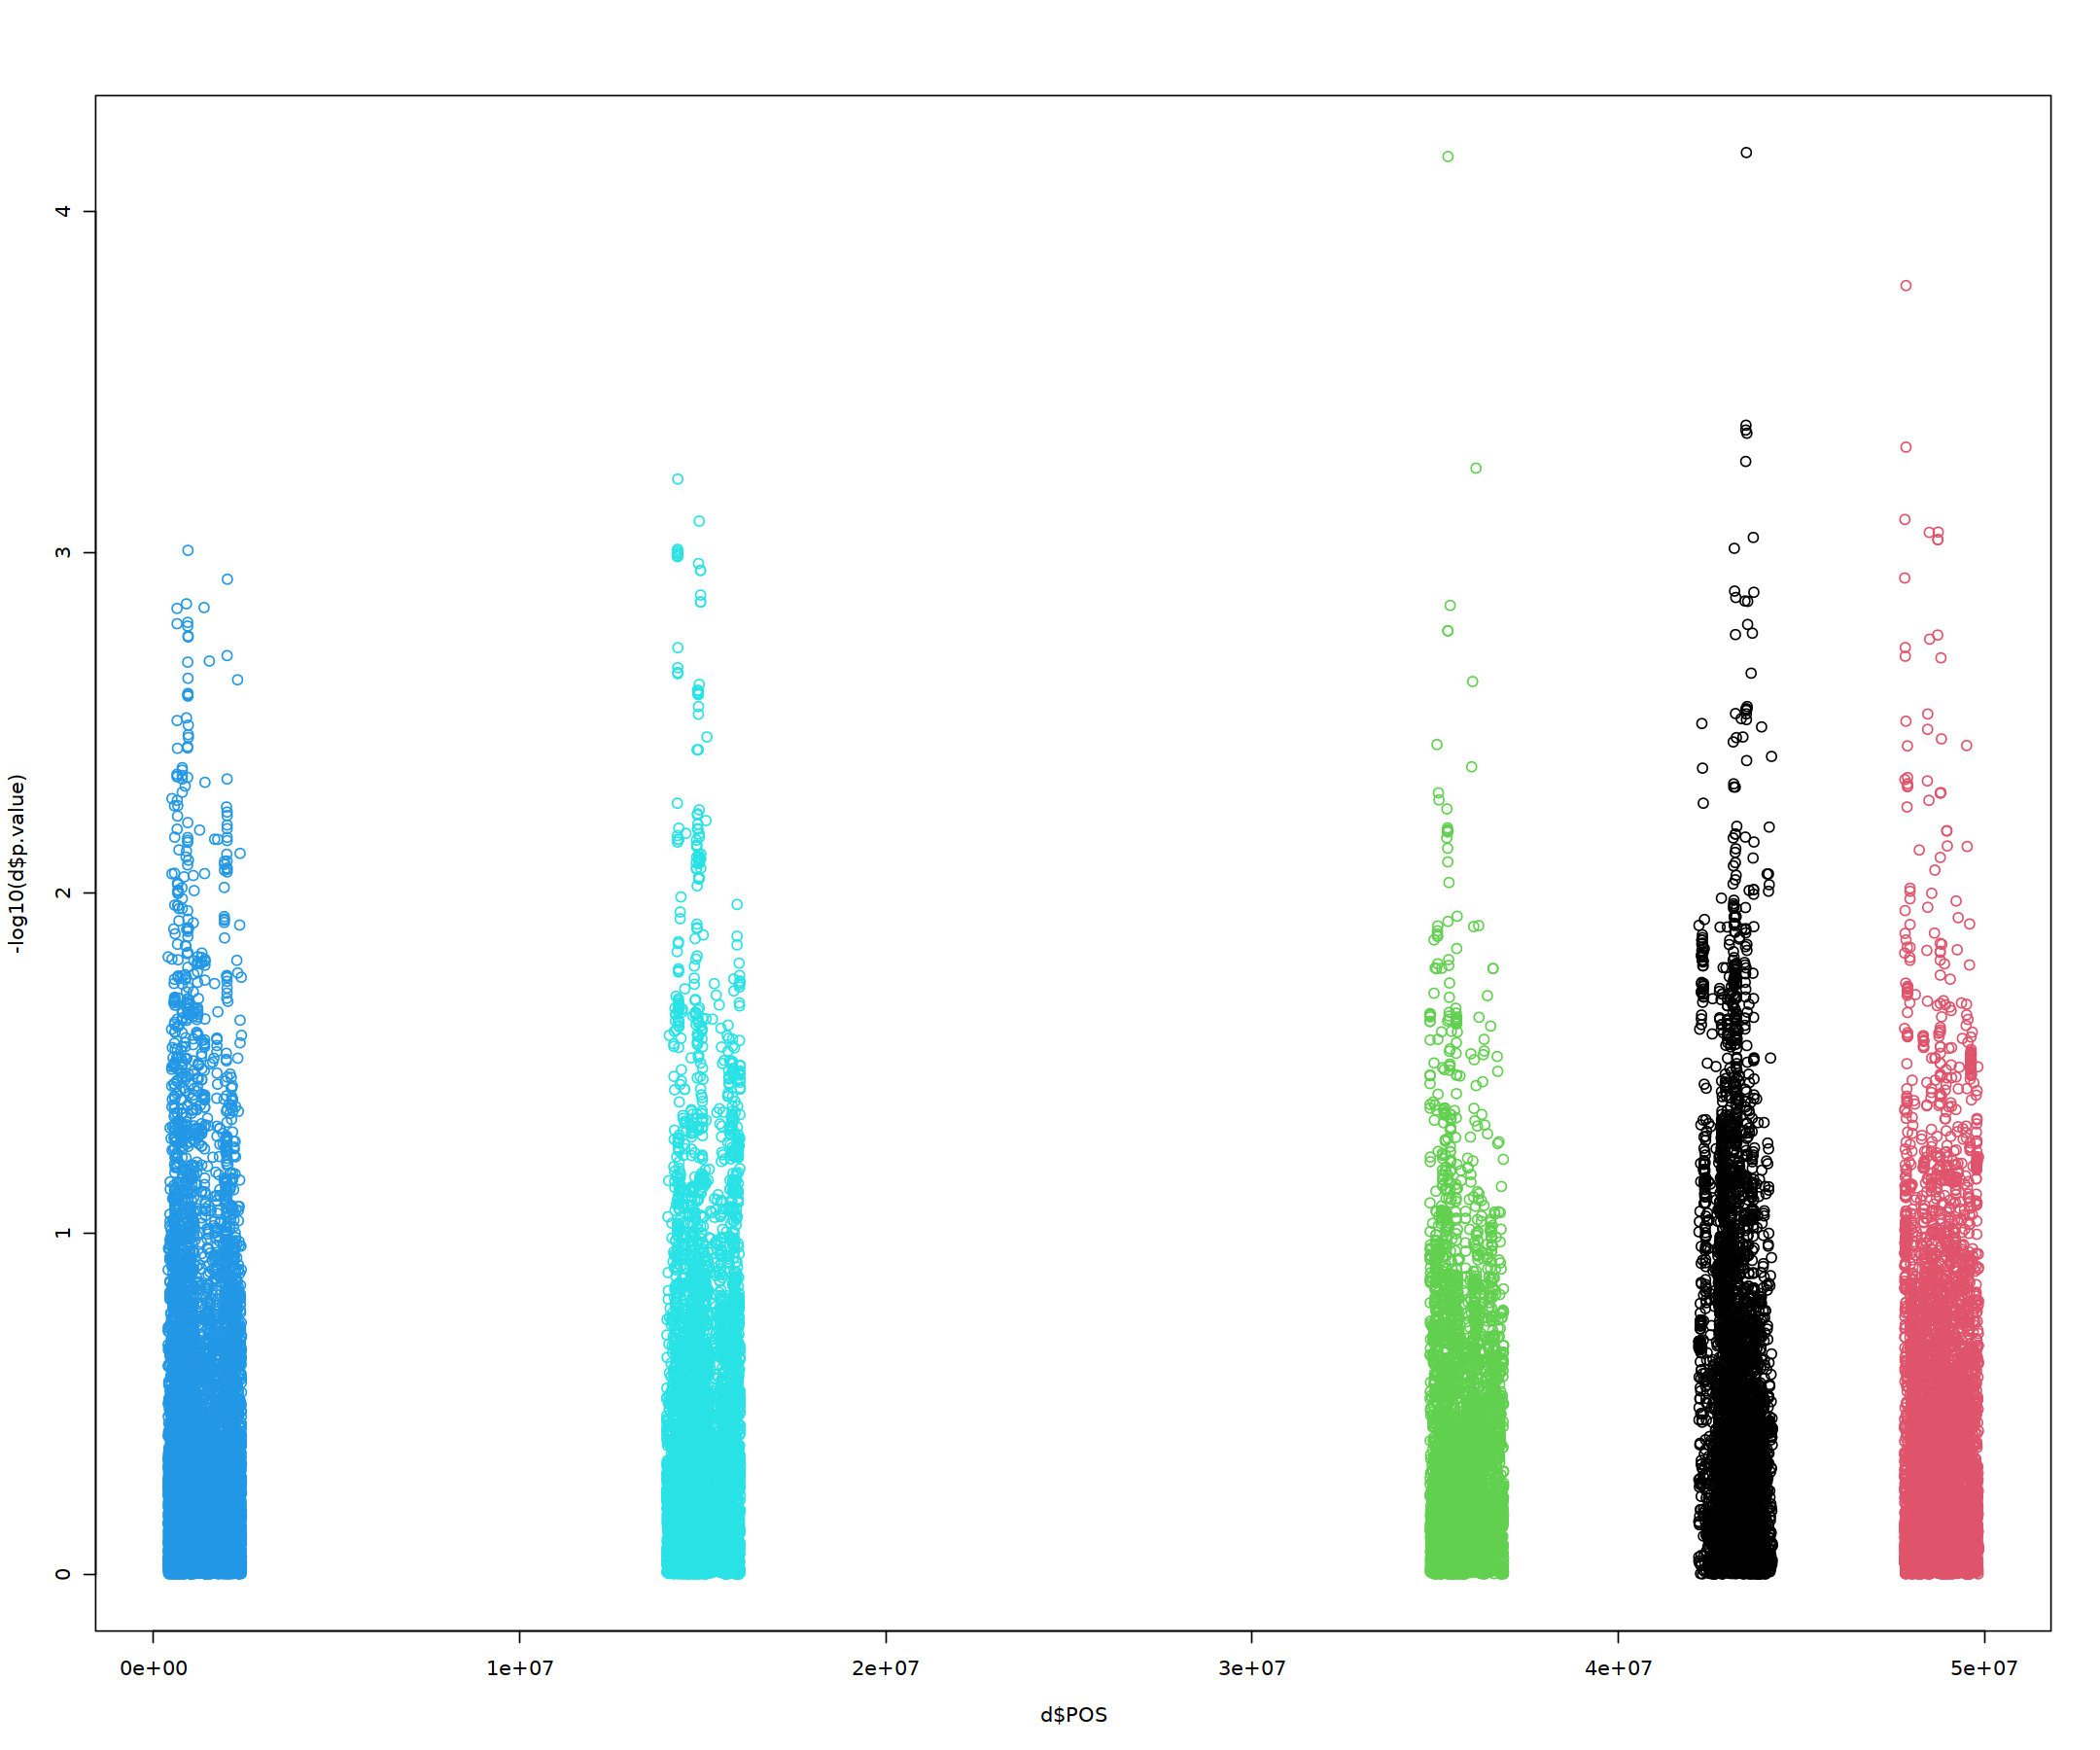

In [365]:
plot(y=-log10(d$p.value), x=d$POS, col = d$cluster)
#for (i in 1:nrow(genes)) points(x=seq(genes$start[i]-1e5, genes$end[i]+1e5, length.out=100), y=rep(1.1, 100))
#text(x=genes$start, y=1.12, labels = genes$gene, cex = 0.8)

In [ ]:
is_overlapping <- function(x1,x2,y1,y2){
    return(max(x1,y1) <= min(x2,y2))
    }

which_overlap <- function(x1, x2, y1, y2){
    nx <- length(x1)
    ny <- length(y1)
    index <- lapply(1:nx, function(i){
        index <- which(unlist(lapply(1:ny, function(j){
            x1i <- x1[i]
            x2i <- x2[i]
            y1j <- y1[j]
            y2j <- y2[j]
            stopifnot(x1i <= x2i)
            stopifnot(y1j <= y2j)
            overlap <- is_overlapping(x1i, x2i, y1j, y2j)
        })))
        return(unlist(index))
    })
    # ensure that missing indexes are NAs
    index[!(index %in% 1:ny)] <- NA
    return(unlist(index))
    }

In [ ]:
get_analysis_stats_df <- function(files, sig_p = (0.05 / (320*4000))){
    ribbon_p <- 0.95
    d <- do.call(rbind, lapply(files, function(f){
        stopifnot(file.exists(f))
        #print(f)
        d <- fread(f)
        d <- d[d$AC_Allele2>=8,]
        if (is.numeric(d$p.value)){
            if (nrow(d) > 0){
                # read from conditional analysis if present
                conditional_markers <- FALSE
                if ("p.value_c" %in% colnames(d)) {
                    d$p.value <- d$p.value_c
                    conditional_markers <- TRUE
                }
                
                # map to to rigt genename
                d$ensembl_gene_id = d$MarkerID
                d$hgnc_symbol <- ensembl_to_hgnc[d$ensembl_gene_id]
                #print(sum(is.na(d$hgnc_symbol)))
                #print(sum(is.na(d$ensembl_gene_id)))
                bool <- is.na(d$hgnc_symbol) | d$hgnc_symbol == ""
                d$hgnc_symbol[bool] <- d$ensembl_gene_id[bool]
                #print(d$hgnc_symbol[bool])
                
                
                # get phenotype
                analysis <- basename(f)
                analysis <- stringr::str_extract(analysis, "200k_.+pLoF_damaging_missense")
                analysis <- gsub("200k_", "", analysis)
                analysis <- gsub("_pLoF_damaging_missense", "", analysis)
                
                # calculate deflation
                d$KC <- d$AC_Allele2 / 2
                inflation <- calc_inflation(d$p.value)
                
                # how many significant hits
                sig_hits <- sum(d$p.value < sig_p)                
                sig_hits_1_case_ko <- sum((d$p.value[d$N_case_hom == 1] < sig_p))
                sig_hits_2_case_ko <- sum((d$p.value[d$N_case_hom >= 2] < sig_p))    
                
                # how many genes did we test?
                
                genes_tested <- length(unique(d$ensembl_gene_id[grepl("ENSG",d$ensembl_gene_id)]))
                sig_genes <- d[d$p.value < sig_p,]
                sig_genes <- sig_genes[order(sig_genes$p.value),]
                sig_genes <- paste0(sig_genes$hgnc_symbol, collapse = ';')
                
                
                # was PRS run?
                prs <- grepl("locoprs", f)
                
                dt <- data.table(
                    analysis,
                    inflation,
                    genes_tested,
                    sig_hits,
                    sig_hits_1_case_ko,
                    sig_hits_2_case_ko,
                    conditional_markers,
                    prs
                    #sig_genes
                )
      
            return(dt)
            } else {
                return(NULL)
            }
        } else {
            write(paste0(f, "was excluded because p-value col was invalid."), stdout())   
        }
    }))
    return(d)
}